In [1]:
import xarray as xr
import numpy as np
import string
import os
import math
import matplotlib.pyplot as plt
import gsw
from datetime import datetime, timedelta
import pandas as pd
import importlib
# from gptide import cov
from gptide import GPtideScipy
from gptide import stats as gpstats
from scipy import signal as sg
# from s3fs import S3FileSystem, S3Map
import scipy
from speccy import utils as ut
from scipy import stats
from speccy import sick_tricks as gary
from scipy.special import kv as K_nu
from scipy.special import gamma
from scipy.optimize import minimize
# mle function import
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [2]:
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = [10, 10]
#np.set_printoptions(threshold=sys.maxsize)
plt.rcParams['animation.embed_limit'] = 2**128

# Import the dataset of internal wave amplitude with decomposed modes

In [4]:
from functions import Processing
importlib.reload(Processing)
ds_dictionary,A_n_dict,Time_dict, Start_date_dict = Processing.Read_PL3_data('PL3 Stacked data_mode_3 - density fit - single_tanh', 
                                                                              percentage=0.80,window_size_days = 170) #excluding the overfitting and performing data segmentation
Site_names,Lat_list,Lon_list = Processing.Extract_site_info(ds_dictionary)

d2spike not available
pyODAS not found, not importing pIMOS.xrwrap.rsi_vmp
No .afloatconfig config file found!
There are 67 raw PL3 data (no windowing)
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
duartion is smaller than window length
NWSLYN_P47_0 has over-fitting 100.10408397845342%
NWSLYN_P48_0 has over-fitting 104.78115110014865%
NWSLYN_P52_0 has over-fitting 104.23583252129984%
NWSROW_P55_0 has over-fitting 106.12938242491146%
duartion is smaller than window length
ITFTIS_P0_0: 5688 (11.62%) NaN values. Dataset excluded.
ITFTIS_P6_0: 6114 (12.49%) NaN values. Dataset excluded.
ITFTIS_P7_0: 11740 (23.98%) NaN values. Dataset excluded.
ITFTIS_P9_0: 12612 (25.76%) NaN values. Dataset excluded.
ITFTIS_P10_0: 14868 (30.37%) NaN values. Dataset excluded.
ITFTIS_P

In [5]:
#exclude the deep mooring
exclude_keywords = ['ITFTIS', 'KIM400']
ds_dictionary = {k: v for k, v in ds_dictionary.items() if not any(kw in k for kw in exclude_keywords)}
A_n_dict = {k: v for k, v in A_n_dict.items() if not any(kw in k for kw in exclude_keywords)}
Time_dict = {k: v for k, v in Time_dict.items() if not any(kw in k for kw in exclude_keywords)}
Start_date_dict = {k: v for k, v in Start_date_dict.items() if not any(kw in k for kw in exclude_keywords)}
filtered = [(site, lat, lon)
    for site, lat, lon in zip(Site_names, Lat_list, Lon_list)
    if all(kw.lower() not in site.lower() for kw in exclude_keywords)]
# Unpack back to separate lists
Site_names, Lat_list, Lon_list = map(list, zip(*filtered))

In [6]:
#Principal lunar semidiurnal
M2_freq = 0.0805*24 #cpd
M4_freq = 2*M2_freq
#Princinpal lunar diurnal
O1_freq = 0.0387*24 #cpd
#Lunisolar diurnal
K1_freq = 0.0418*24 #cpd
#Principal solar semidiurnal
S2_freq = 0.0833*24 #cpd
# Calculate the Coriolis frequency
f_coriolis = 4*np.pi/86400 * np.sin(Lat_list[0]*np.pi/180)
f_coriolis_cpd = np.abs(f_coriolis*86400/(2*np.pi))
xcoords = [f_coriolis_cpd, O1_freq, K1_freq,M2_freq,S2_freq]

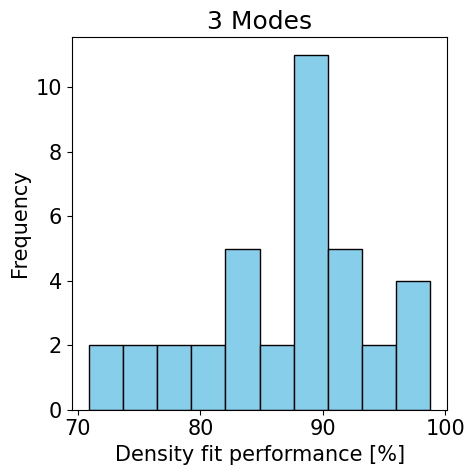

In [7]:
from functions import Plot_figure
importlib.reload(Plot_figure)
plt.rcParams['figure.figsize'] = [5, 5]
mode_fraction_median_dict = Plot_figure.Plot_Density_fit_performance(ds_dictionary,bins=10)

In [8]:
for site in Site_names:
    site_list = []
    for i in mode_fraction_median_dict:
        if site in i:
            site_list.append(mode_fraction_median_dict[i])
    print('{} has a median of density fit fraction of {}%'.format(site,np.round(np.median(site_list),2)))
print('All {}%'.format(np.round(np.median(list(mode_fraction_median_dict.values())),2)))

KIM200 has a median of density fit fraction of 92.31%
NWSBAR has a median of density fit fraction of 76.9%
NWSBRW has a median of density fit fraction of 88.06%
NWSLYN has a median of density fit fraction of 96.05%
NWSROW has a median of density fit fraction of 85.26%
PIL200 has a median of density fit fraction of 89.19%
All 88.49%


## obs Example 

In [10]:
from functions import Plot_figure
importlib.reload(Plot_figure)

<module 'functions.Plot_figure' from 'C:\\Users\\21924032\\GitHub\\Normal-Mode-Decomposition-of-the-Internal-Wave\\functions\\Plot_figure.py'>

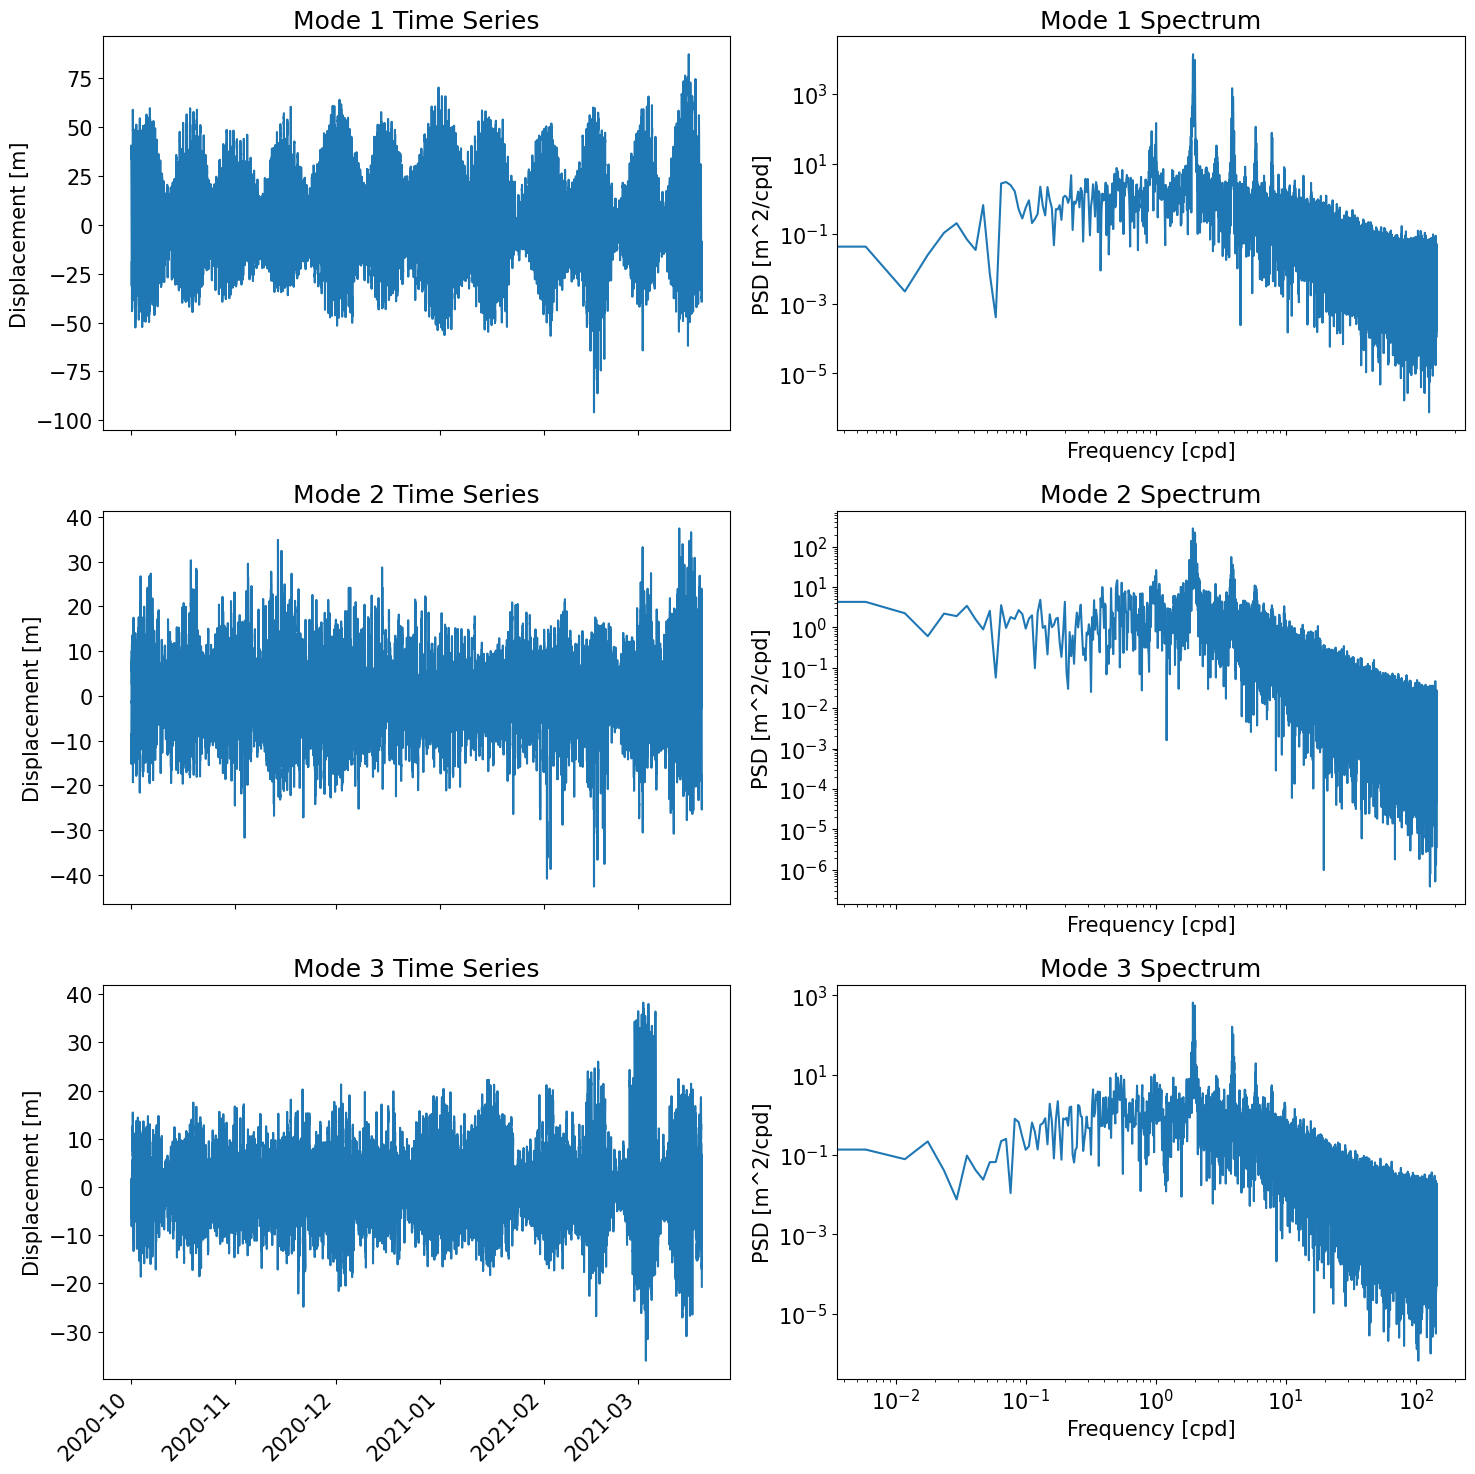

In [28]:
example_name = 'NWSBRW_P39_0'
plt.rcParams['figure.figsize'] = [15, 15]
Plot_figure.Plot_IW_amp_spectrum(Time_dict[example_name],A_n_dict[example_name],nmodes=len(A_n_dict[example_name])) 

## Map

In [37]:
shallow_sites = ['NWSLYN','NWSBRW','KIM200','NWSROW','PIL200','NWSBAR',]
shallow_lat, shallow_lon = zip(*[(lat, lon) for site, lat, lon in zip(Site_names, Lat_list, Lon_list) if site in shallow_sites])

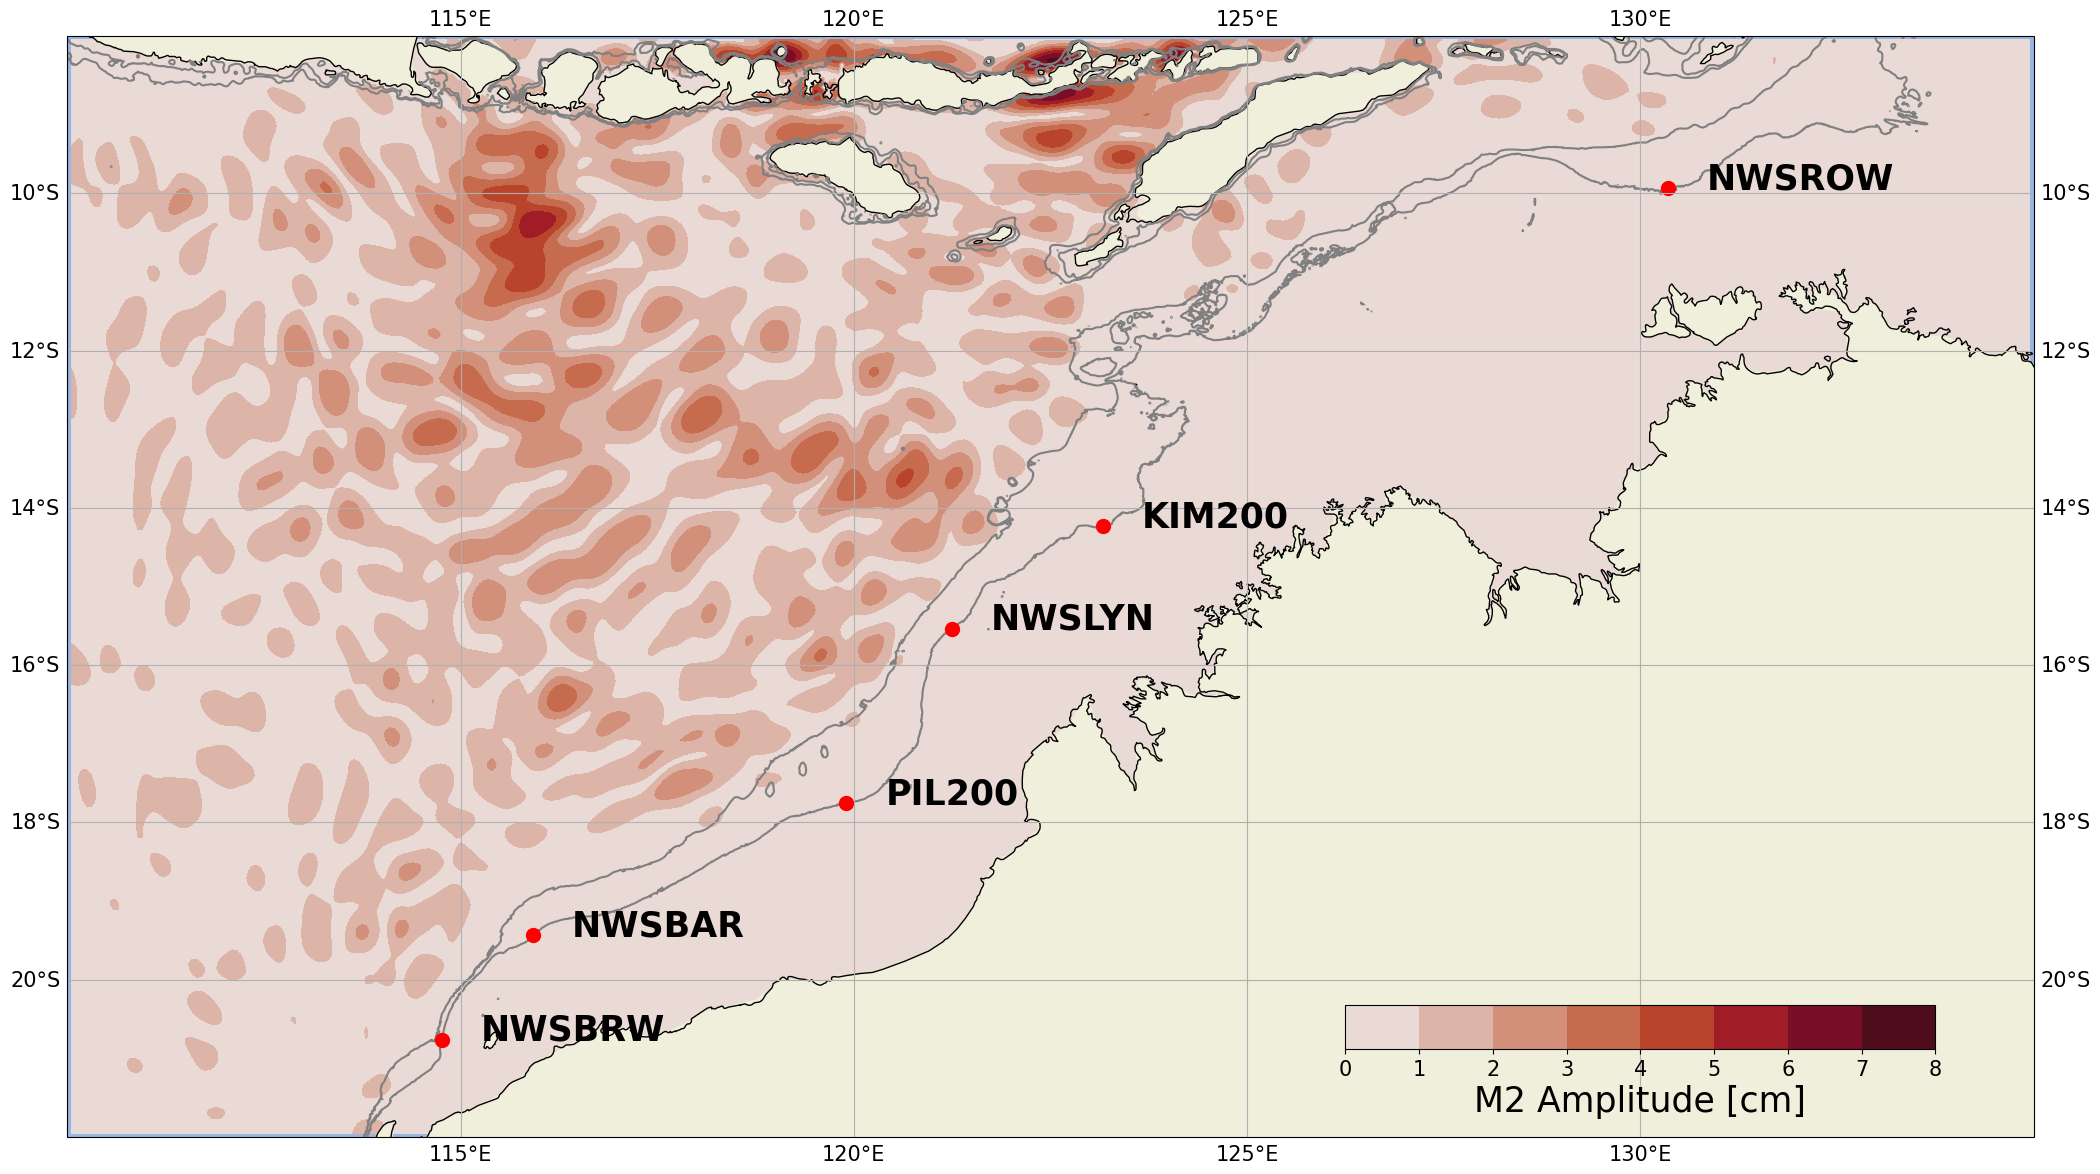

In [39]:
shallow_sites = ['NWSLYN','NWSBRW','KIM200','NWSROW','PIL200','NWSBAR',]
shallow_lat, shallow_lon = zip(*[(lat, lon) for site, lat, lon in zip(Site_names, Lat_list, Lon_list) if site in shallow_sites])
importlib.reload(Plot_figure)
Bathmetry_file  = 'gebco_2023_n-7.6245_s-24.5874_w109.6436_e135.7471.nc'
M2tide_SSH_file = 'HRET_v8.1_compressed.nc'
plot_map,ax_map = Plot_figure.Plot_map(Bathmetry_file,M2tide_SSH_file,shallow_sites,shallow_lat, shallow_lon)
plot_map.savefig('mooring map.pdf', bbox_inches='tight')

# HA analysis

In [41]:
from functions import Harmonics
importlib.reload(Harmonics)

<module 'functions.Harmonics' from 'C:\\Users\\21924032\\GitHub\\Normal-Mode-Decomposition-of-the-Internal-Wave\\functions\\Harmonics.py'>

In [42]:
Mean_params_dict ={}
Yd_mean_dict ={}
ϵ_dict ={}
F_ϵ_dict ={}
Puu_ϵ_dict ={}
HA_var_dict = {}
HA_M2_var_dict = {}
HA_S2_var_dict = {}

for i in A_n_dict:
    Mean_params_list, Yd_mean_list,ϵ_list,F_ϵ_list,Puu_ϵ_list = Harmonics.Cal_HA(Time_dict[i],A_n_dict[i])
    Mean_params_dict[i] = Mean_params_list
    Yd_mean_dict[i]     = Yd_mean_list
    ϵ_dict[i]           = ϵ_list
    F_ϵ_dict[i]         = F_ϵ_list
    Puu_ϵ_dict[i]       = Puu_ϵ_list
    #calculate HA var
    HA_var_list = Harmonics.Cal_var_from_mean_funcs(Yd_mean_list)
    HA_var_dict[i]  = HA_var_list    
    #calculate HA var at M2 and S2
    M2_mean_list = [np.array([i[2], i[6]]) for i in Mean_params_list]
    HA_M2_var_list = Harmonics.Cal_var_from_mean_params(M2_mean_list)
    HA_M2_var_dict[i]  = HA_M2_var_list  
    S2_mean_list = [np.array([i[3], i[7]]) for i in Mean_params_list]
    HA_S2_var_list = Harmonics.Cal_var_from_mean_params(S2_mean_list)
    HA_S2_var_dict[i]  = HA_S2_var_list    

In [43]:
def Plot_HA_result(time_list,A_list,xcoords,
                   Mean_params_list,ϵ_list,Yd_mean_list,
                   F_ϵ_list,Puu_ϵ_list, mode_number=0):
    
    x = time_list[mode_number]
    y = A_list[mode_number]
    ϵ = ϵ_list[mode_number]
    yd_mean = Yd_mean_list[mode_number]
    #calculate spectrum
    Δ = (x[1]-x[0]).astype('float')/1e9/86400
    Δ = Δ.values
    F_obs,P_obs = Processing.Cal_periodogram(y.values,Δ)

    plt.subplot(2, 1, 1)
    idx = 15000
    plt.plot(x[10000:idx],y[10000:idx],label='Observation',alpha=0.8)
   # plt.plot(x[10000:idx],ϵ[10000:idx],'-.',label = 'Residual')
    plt.plot(x[10000:idx],yd_mean[10000:idx],label='Harmonic analysis',linewidth=2)
    plt.ylabel('Amplitude (m)')
    # plt.grid(b=True,ls=':')
    #plt.title('Time series mode {}'.format(mode_number+1))
    plt.legend(loc="lower right")
    plt.xticks(rotation=45)
    plt.tight_layout()

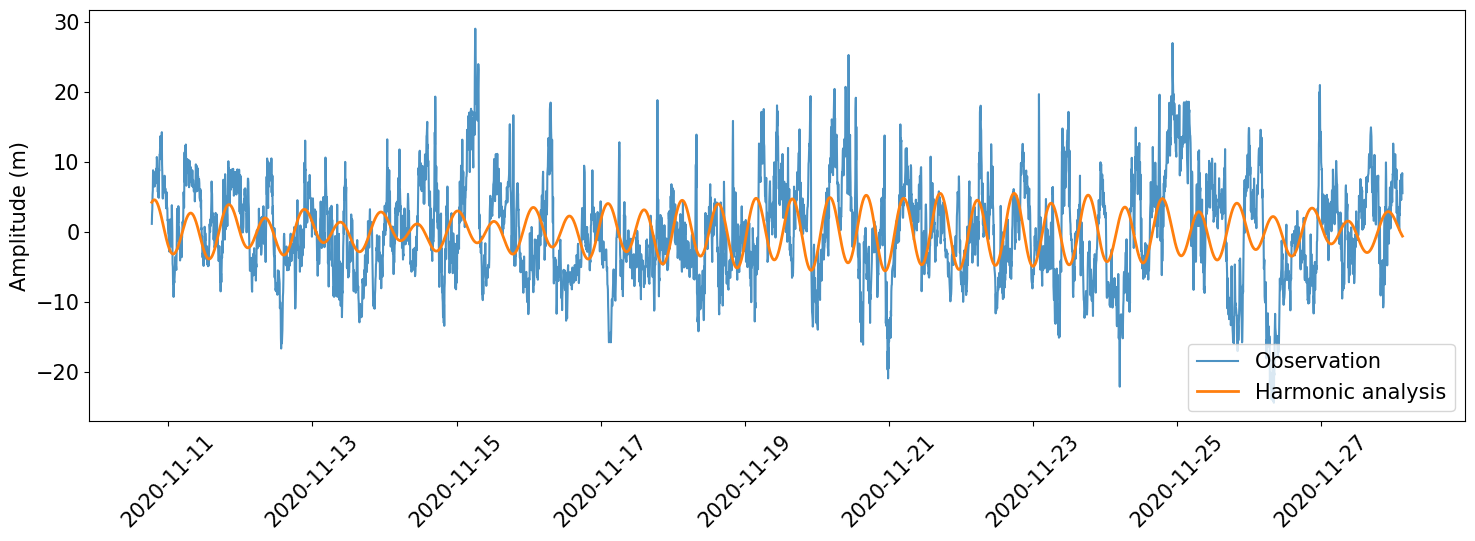

In [45]:
from functions import Plot_figure
importlib.reload(Plot_figure)
importlib.reload(Processing)
example_name = 'NWSBAR_P29_0'
plt.rcParams['figure.figsize'] = [15, 10]
Plot_HA_result(Time_dict[example_name],A_n_dict[example_name],
                           xcoords,Mean_params_dict[example_name],ϵ_dict[example_name],Yd_mean_dict[example_name],
                            F_ϵ_dict[example_name],Puu_ϵ_dict[example_name], mode_number=0)

## Subset

In [47]:
subset_end_freq = 35 #cpd
peak_bandwidth = 0.2#cpd
M4_freq = 2*0.0805*24 #cpd
M6_freq = 3*0.0805*24 #cpd
f_coriolis_cpd = 0.5
D1_freq = 1 #cpd

subset_dict = {}
F_ϵ_modulated_dict  = {}
Puu_ϵ_modulated_dict={}
Var_residual_dict = {}

for i in F_ϵ_dict:
    subset_dict[i]         = Processing.Subset_freq(F_ϵ_dict[i],f_coriolis_cpd,subset_end_freq,peak_bandwidth,
                                                         Omit=True,omit_freq=(D1_freq,M4_freq,M6_freq))
    F_ϵ_modulated_dict[i]  = Processing.Select_frequency(F_ϵ_dict[i],  subset_dict[i])
    Puu_ϵ_modulated_dict[i]= Processing.Select_frequency(Puu_ϵ_dict[i],subset_dict[i])
    Var_residual_dict[i]   = Processing.Cal_var_from_Periodogram(F_ϵ_modulated_dict[i],Puu_ϵ_modulated_dict[i])

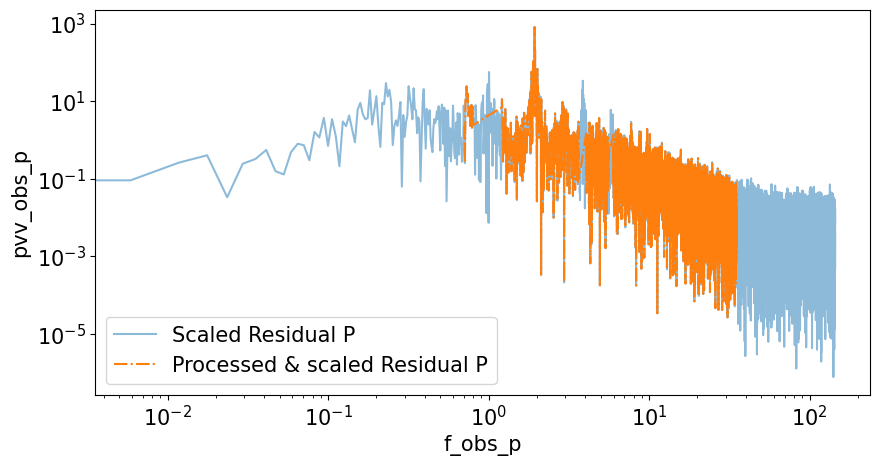

In [49]:
# show an example
plt.rcParams['figure.figsize'] = [10, 5]
mode_number =0
plt.plot(F_ϵ_dict[example_name][mode_number],
         Puu_ϵ_dict[example_name][mode_number],alpha=0.5,label='Scaled Residual P')
plt.plot(F_ϵ_modulated_dict[example_name][mode_number],
         Puu_ϵ_modulated_dict[example_name][mode_number],'-.',label='Processed & scaled Residual P')
plt.legend()
# plt.xlim(0, 5)
plt.ylabel('pvv_obs_p')
plt.xlabel('f_obs_p')
plt.xscale("log")
plt.yscale("log")

## Fit to Obs

In [51]:
from functions import Cov

In [53]:
def M1P1(dx,params):
    M2_freq = 1.93 #cpd
    S2_freq = 2 #cpd
    D2_freq = (S2_freq+M2_freq)/2
    
    η_matern1 = params[0]
    α_matern1 = params[1]
    eta_D2    = params[2]
    tau_D2    = params[3]
    gamma_D2  = params[4]
    
    matern1 = Cov.Matern(dx, (η_matern1,α_matern1),lmbda=3,sigma=1e-6)              #background energy continuum  
    peak2   = Cov.LR_2(dx, (eta_D2,tau_D2,gamma_D2),l_cos=D2_freq) 
    COV = matern1 + peak2 #+ noise
    return COV

def M1P2_2(dx,params):
    M2_freq = 1.93 #cpd
    S2_freq = 2 #cpd

    η_matern1 = params[0]
    α_matern1 = params[1]
    eta_S2    = params[2]
    tau_S2    = params[3]
    gamma_S2  = params[4]
    eta_M2    = params[5]
    tau_M2    = params[6]
    gamma_M2  = params[7]
    
    matern1 = Cov.Matern(dx, (η_matern1,α_matern1),lmbda=3,sigma=1e-6)              #background energy continuum  
    peak2   = Cov.LR_2(dx, (eta_S2,tau_S2,gamma_S2),l_cos=S2_freq) + Cov.LR_2(dx, (eta_M2,tau_M2,gamma_M2),l_cos=M2_freq)
    COV = matern1 + peak2 #+ noise
    return COV

In [55]:
#Initia guess
IG_η_matern = 3
IG_α_matern = 0.9 #impact the slope
IG_eta  = 3
IG_tau   = 3 #impact how wide the brodening of peak is
IG_gamma = 1
Bound_gamma = [0,2]

M1P1_covparams_ic =[IG_η_matern,
                    IG_α_matern,
                    IG_eta,
                    IG_tau,  
                    IG_gamma, ]#Semi-Diurnal frequency         

M1P2_covparams_ic =[IG_η_matern,
                    IG_α_matern,
                    IG_eta,
                    IG_tau,  
                    IG_gamma,
                    IG_eta,
                    IG_tau,
                    IG_gamma ]#Semi-Diurnal frequency      

M1P2_2_parameter_name = ['η_c','α_c','η_S2','τ_S2','γ_S2','η_M2', 'τ_M2','γ_M2']
M1P1_parameter_name = ['η_c','α_c','η_D2','τ_D2','γ_D2',]

In [57]:
%%time
from functions import Optimisation
importlib.reload(Cov)
importlib.reload(Optimisation)

CPU times: total: 0 ns
Wall time: 5.58 ms


<module 'functions.Optimisation' from 'C:\\Users\\21924032\\GitHub\\Normal-Mode-Decomposition-of-the-Internal-Wave\\functions\\Optimisation.py'>

### M1P2_2

In [59]:
%%time
from functions import Optimisation
importlib.reload(Cov)
importlib.reload(Optimisation)
F_model_fit_dict_M1P2 ={}
P_model_fit_dict_M1P2 ={}
Soln_model_fit_dict_M1P2 ={}
Whittle_dict_M1P2 ={}

bound_indices = [4,7]
bounds_list   = [Bound_gamma,Bound_gamma]
#only works for M1P2 AND M1P1
for i in Puu_ϵ_dict:
    F_model_fit_dict_M1P2[i],P_model_fit_dict_M1P2[i],Soln_model_fit_dict_M1P2[i],Whittle_dict_M1P2[i] = Optimisation.Model_fit(Puu_ϵ_dict[i], Time_dict[i],subset_dict[i],
                                                                                                             M1P2_covparams_ic,M1P2_2,
                                                                                                             bound_indices=bound_indices, bounds_list=bounds_list)
    print('Modit fit completed for',i)

Modit fit completed for KIM200_P17_0
Modit fit completed for KIM200_P19_0
Modit fit completed for KIM200_P20_0
Modit fit completed for KIM200_P21_0
Modit fit completed for NWSBAR_P27_0
Modit fit completed for NWSBAR_P28_0
Modit fit completed for NWSBAR_P29_0
Modit fit completed for NWSBAR_P30_0
Modit fit completed for NWSBAR_P31_0
Modit fit completed for NWSBAR_P33_0
Modit fit completed for NWSBAR_P34_0
Modit fit completed for NWSBAR_P35_0
Modit fit completed for NWSBRW_P37_0
Modit fit completed for NWSBRW_P39_0
Modit fit completed for NWSBRW_P40_0
Modit fit completed for NWSBRW_P41_0
Modit fit completed for NWSBRW_P42_0
Modit fit completed for NWSBRW_P43_0
Modit fit completed for NWSBRW_P44_0
Modit fit completed for NWSBRW_P45_0
Modit fit completed for NWSLYN_P46_0
Modit fit completed for NWSLYN_P49_0
Modit fit completed for NWSLYN_P50_0
Modit fit completed for NWSLYN_P51_0
Modit fit completed for NWSLYN_P53_0
Modit fit completed for NWSROW_P54_0
Modit fit completed for NWSROW_P56_0
M

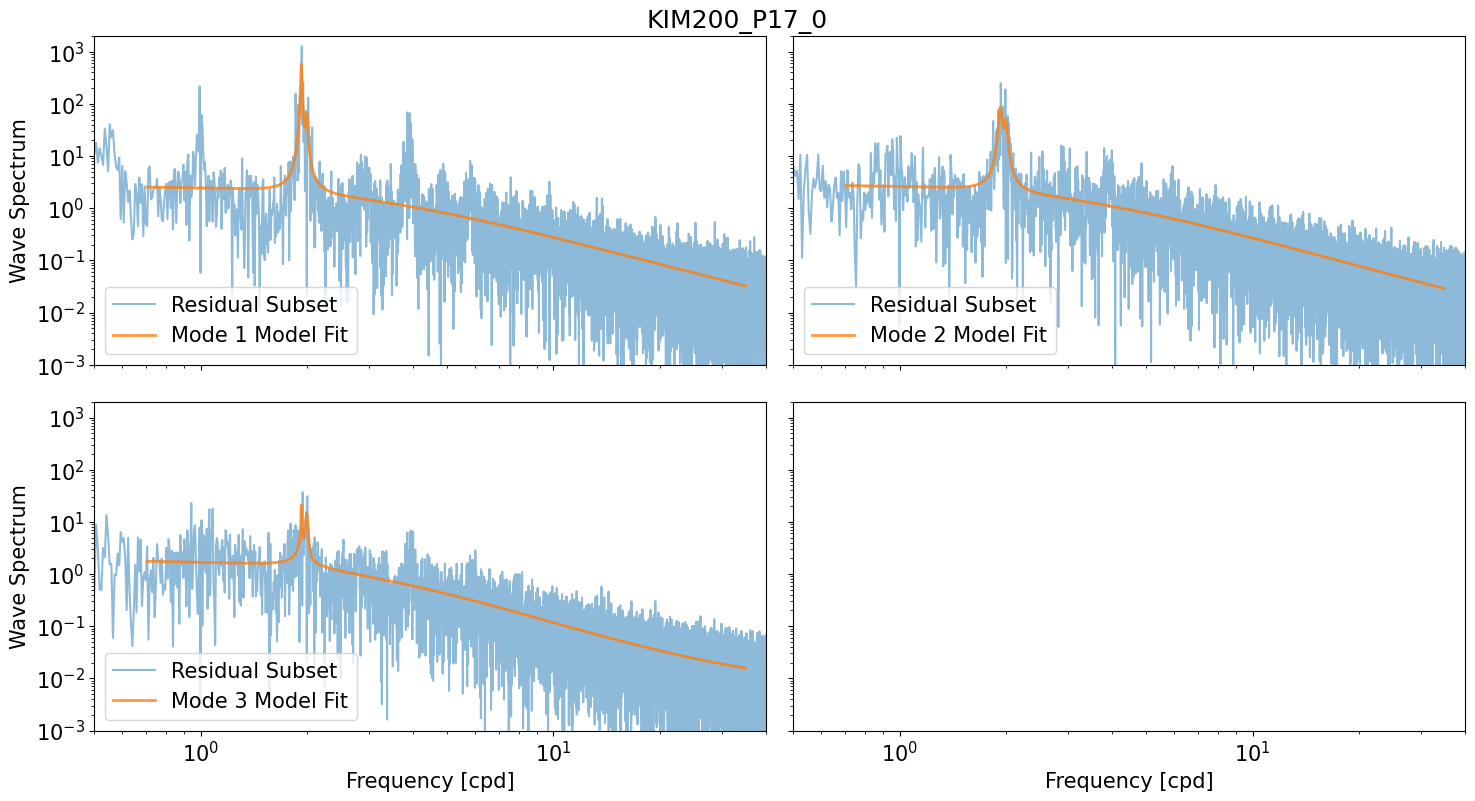

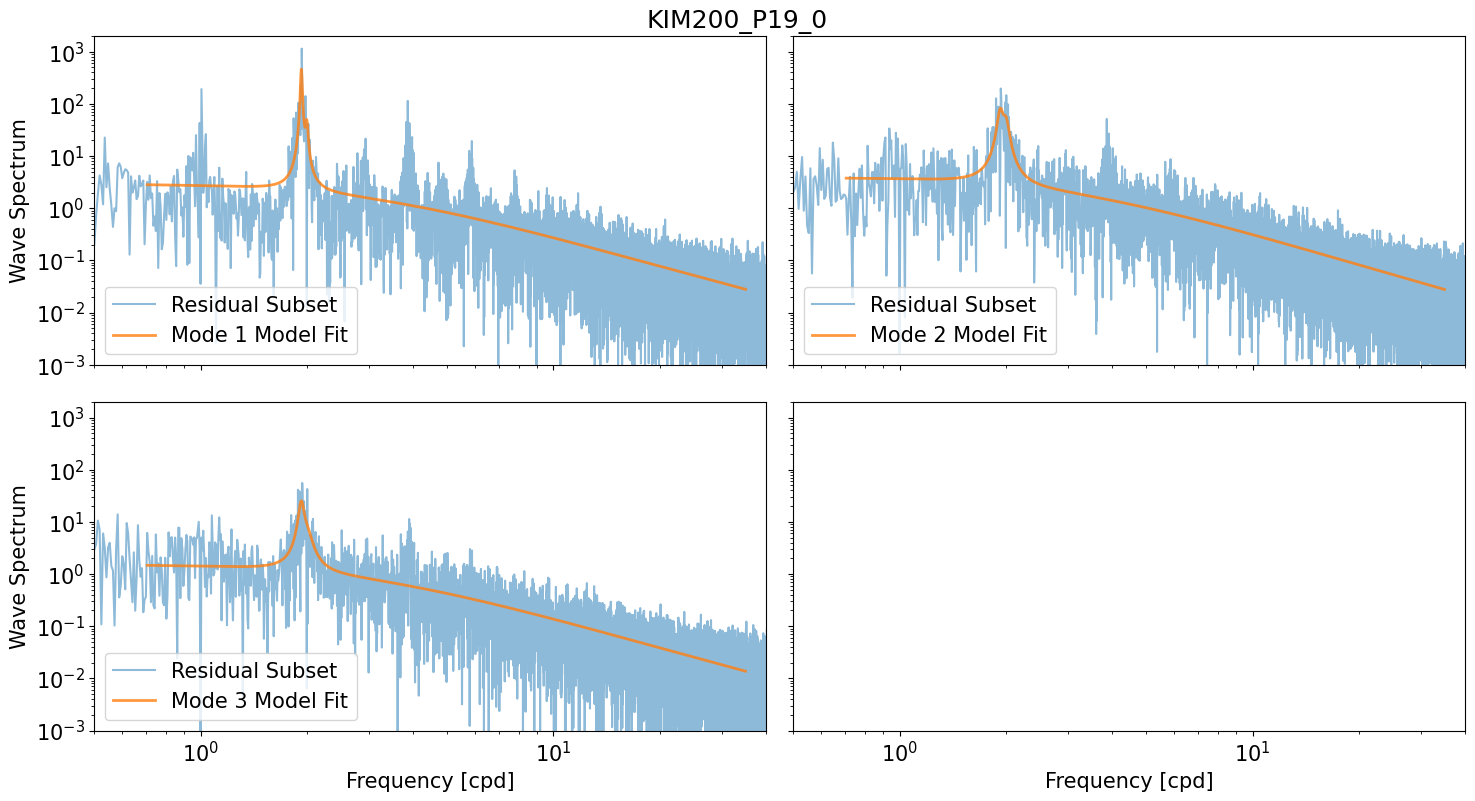

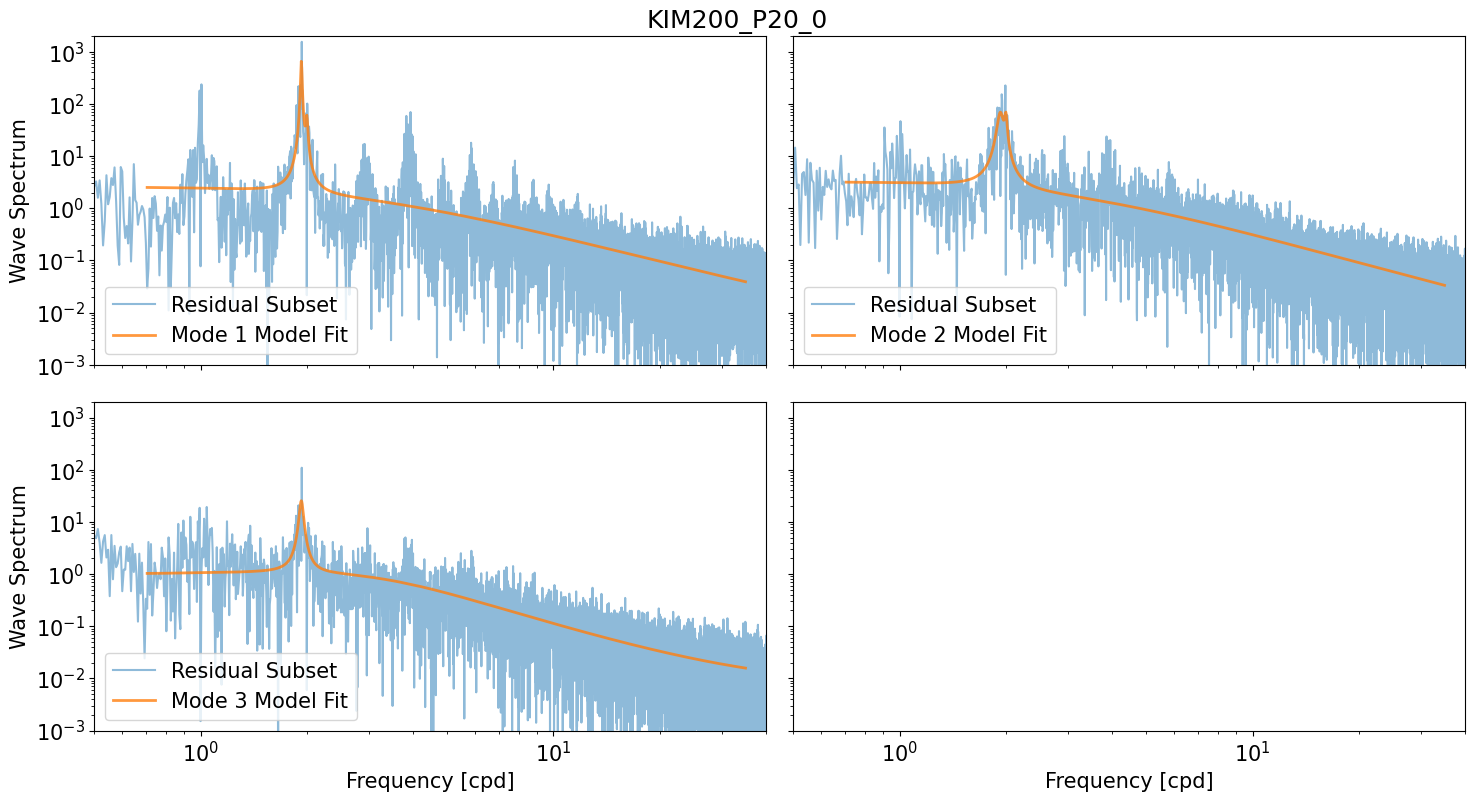

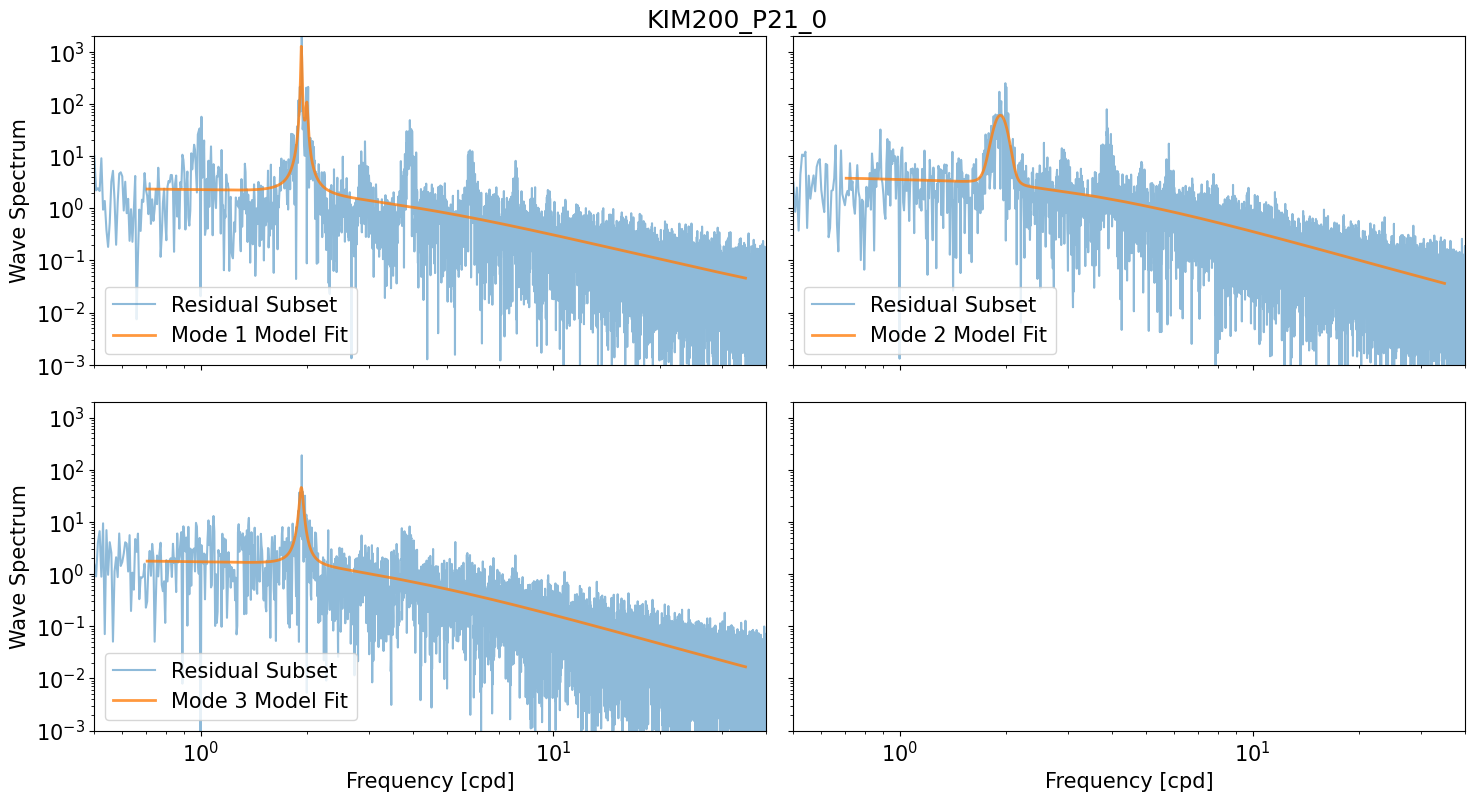

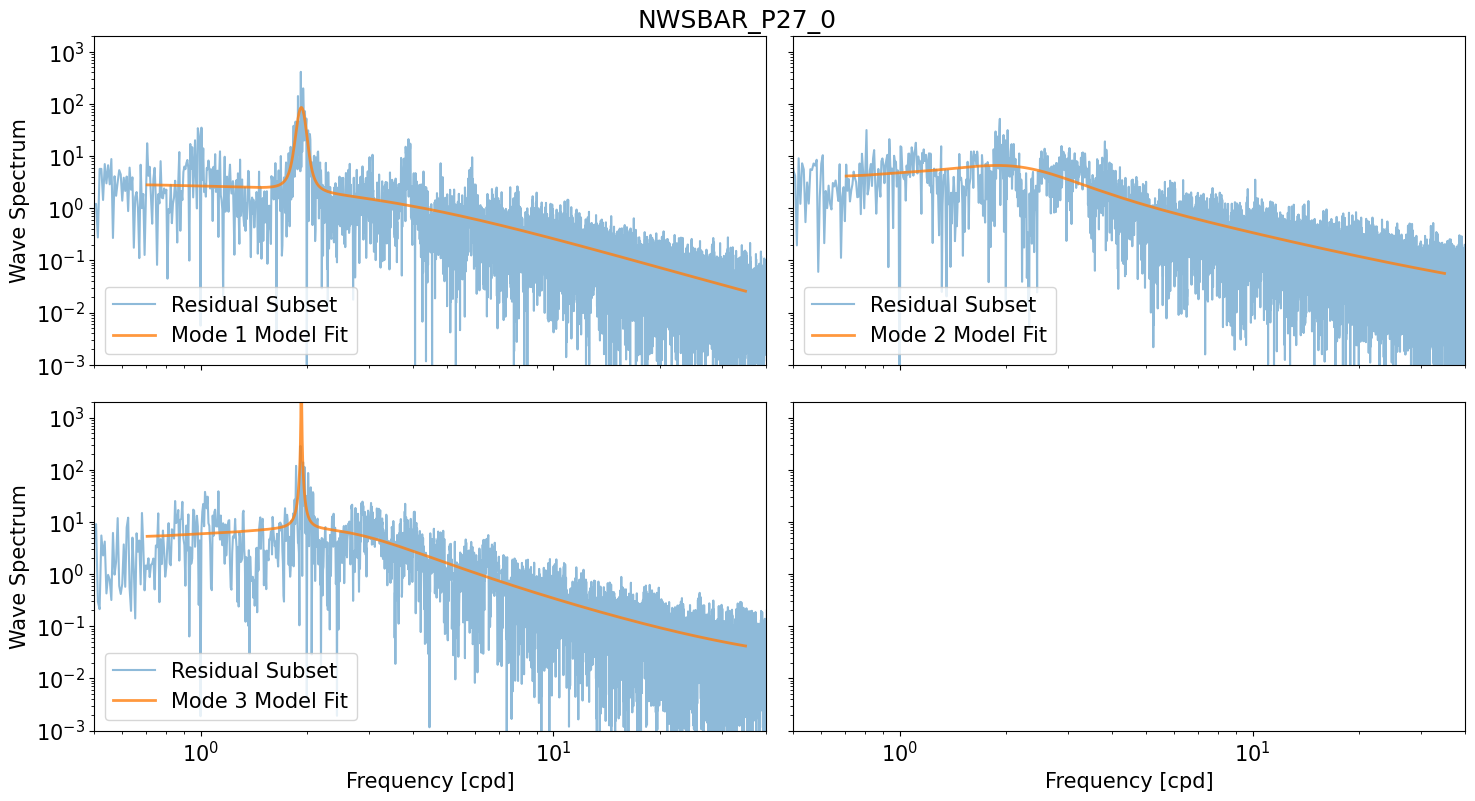

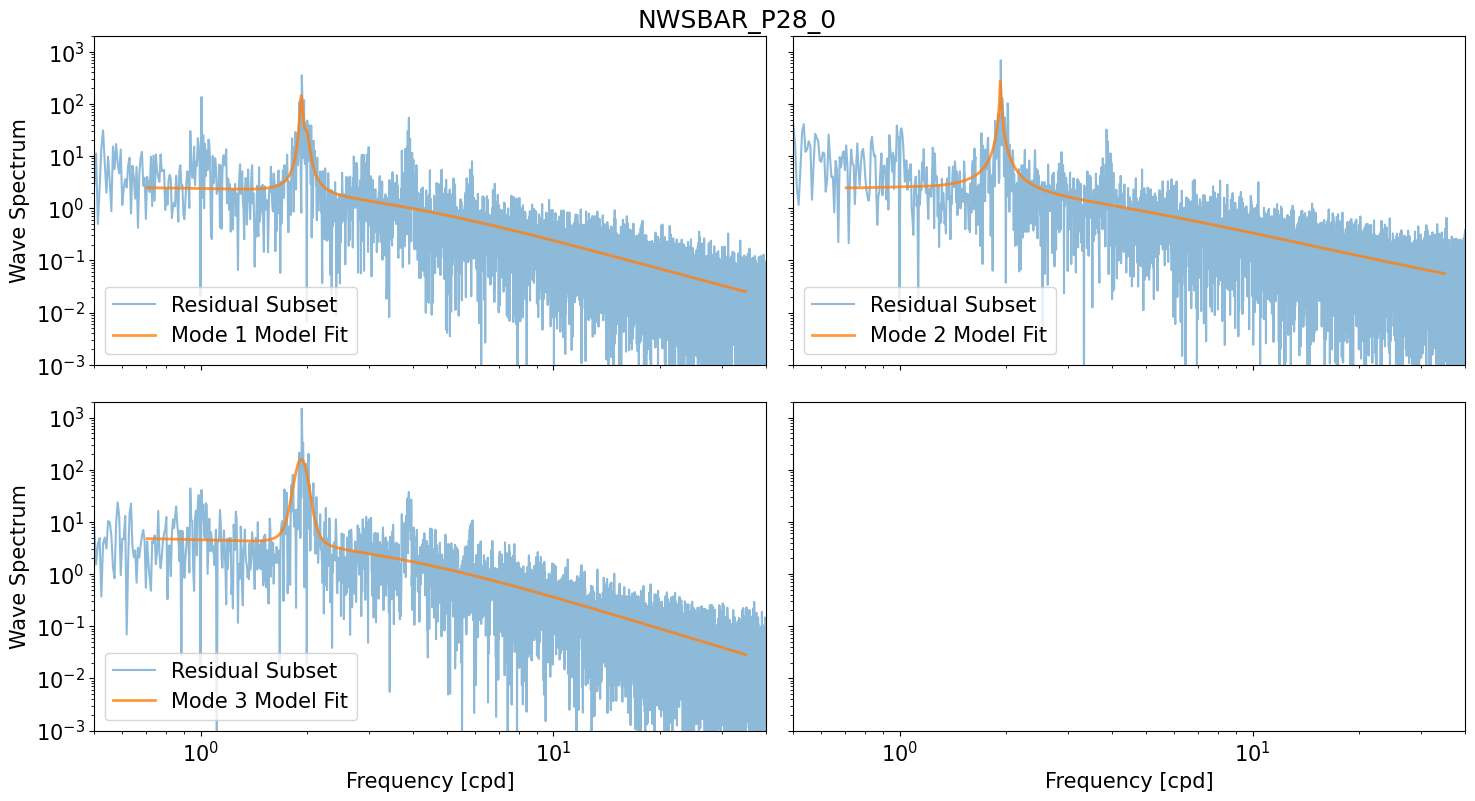

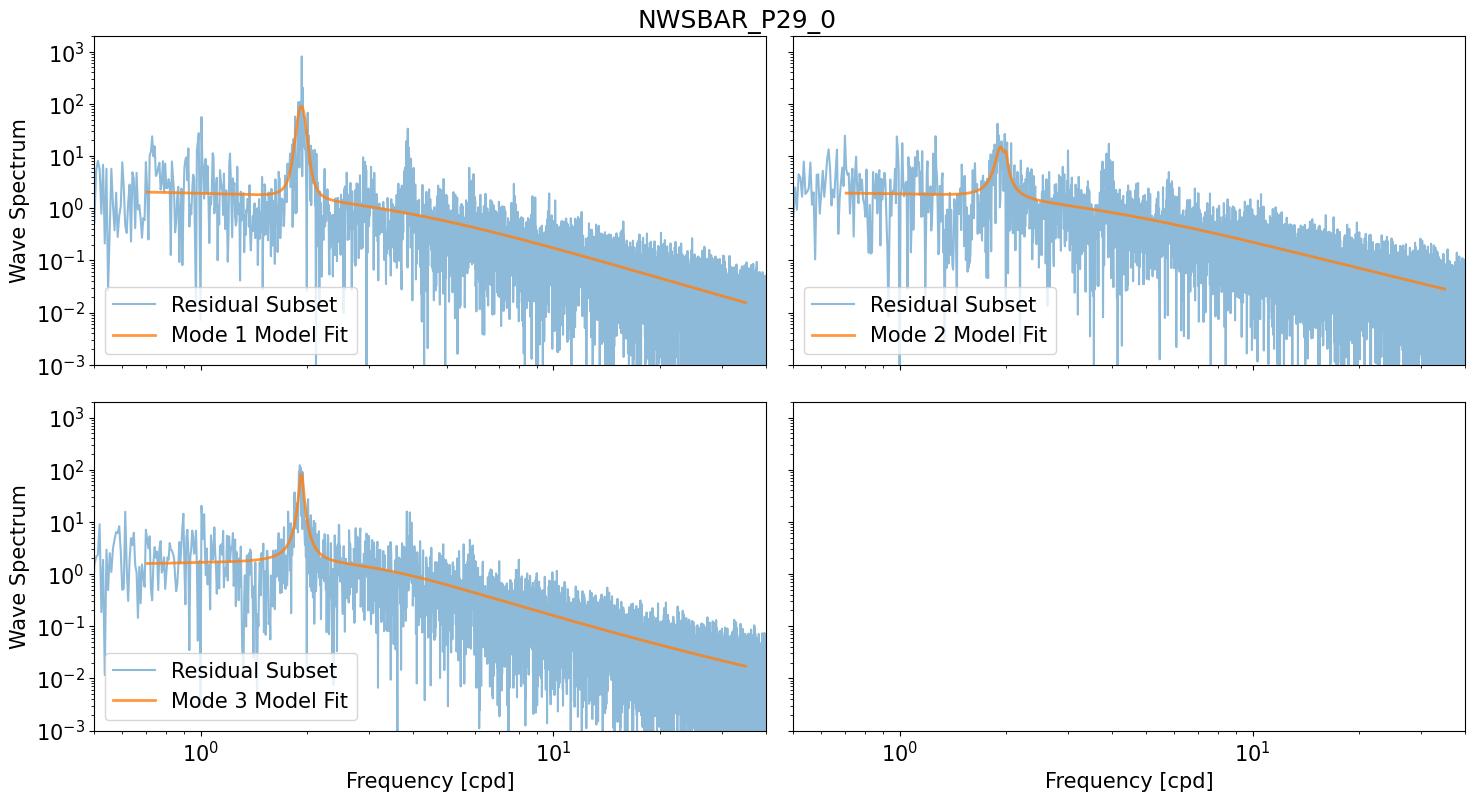

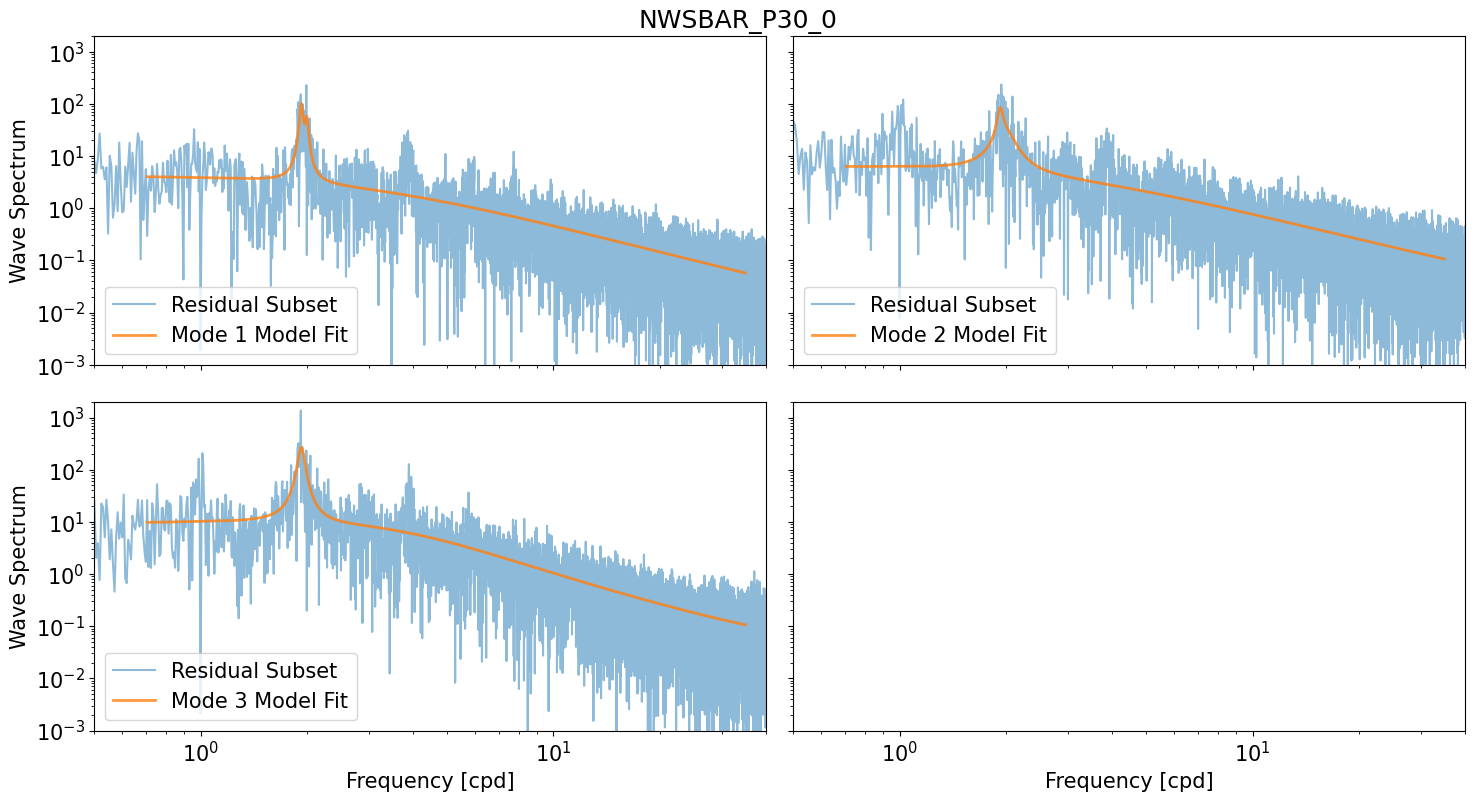

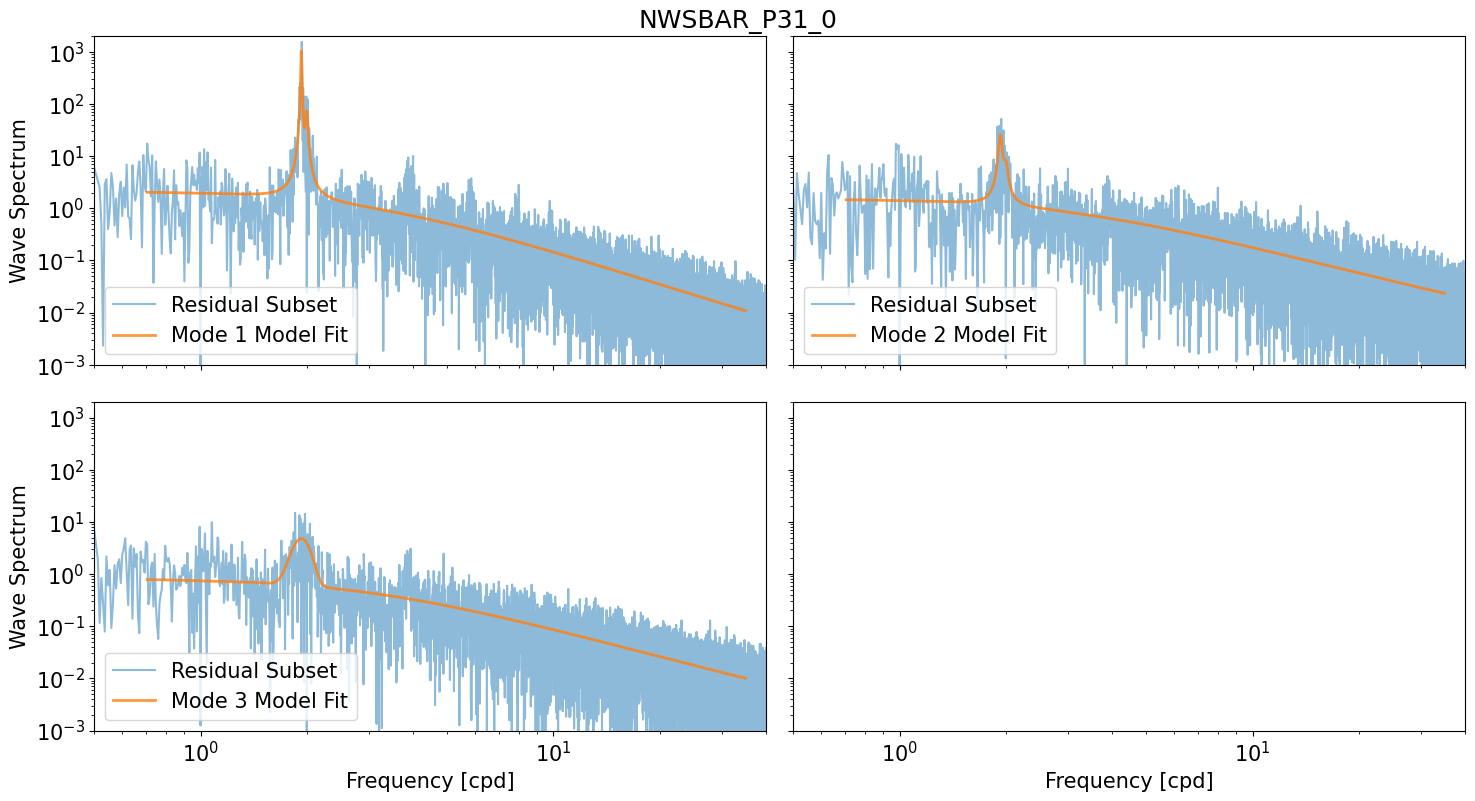

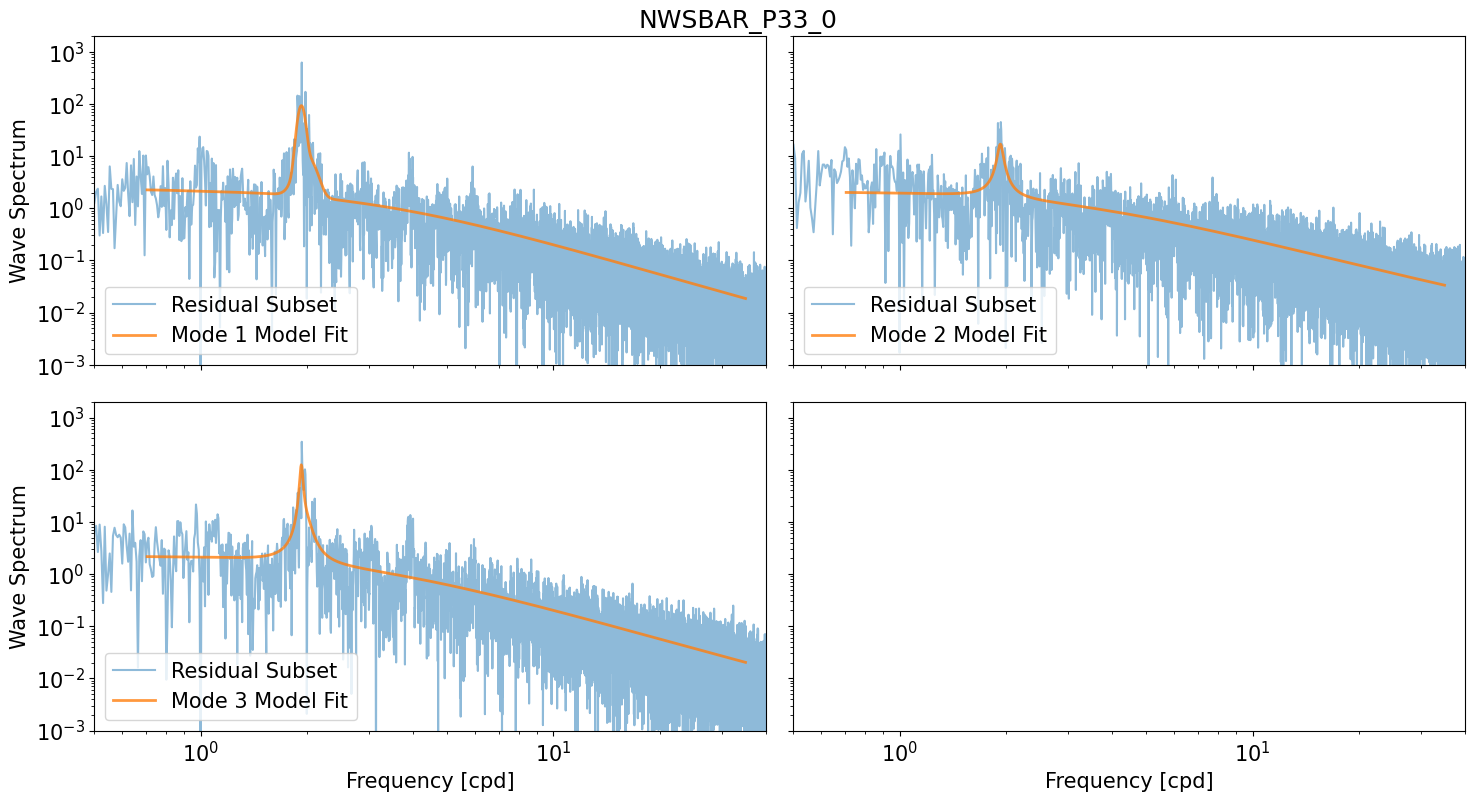

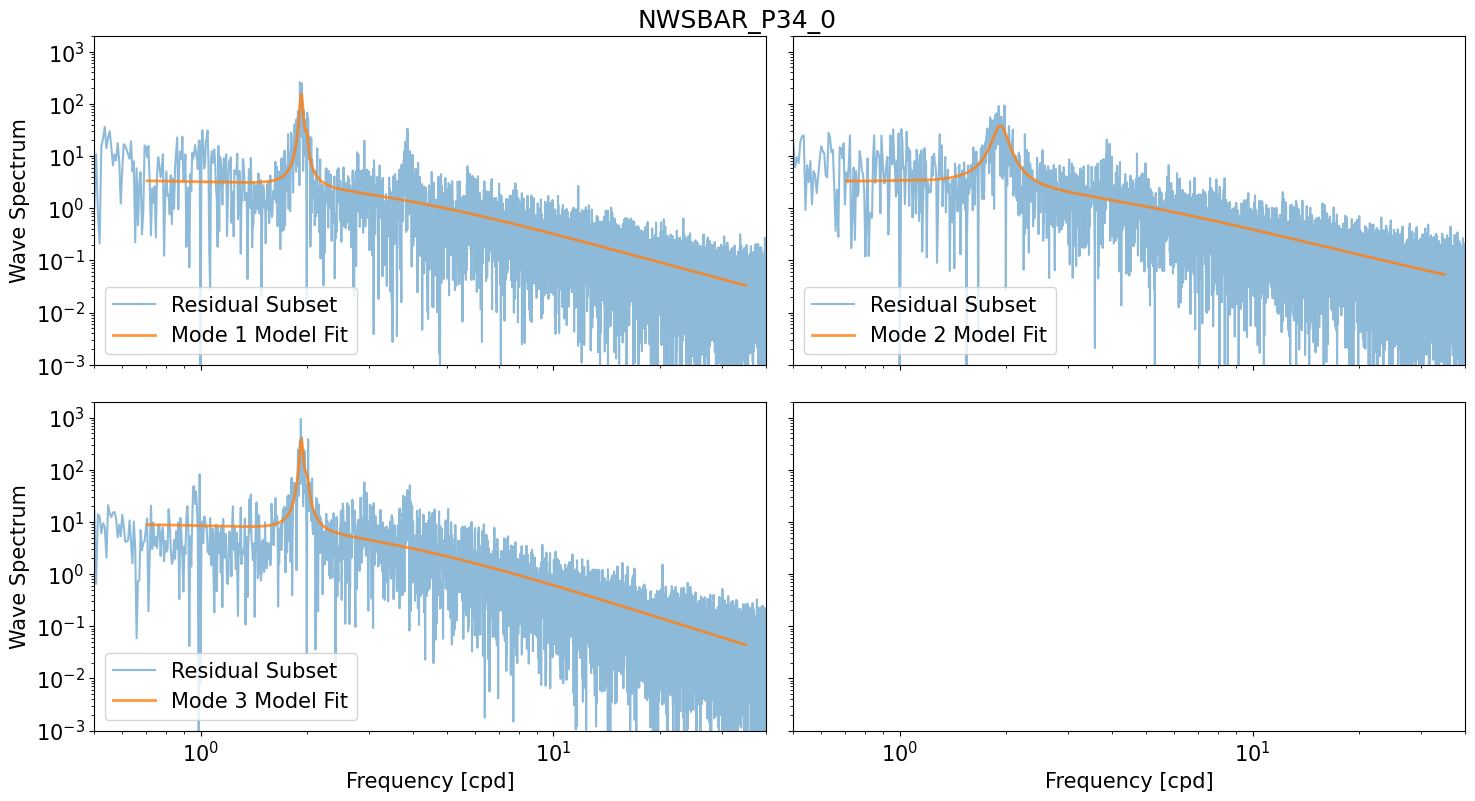

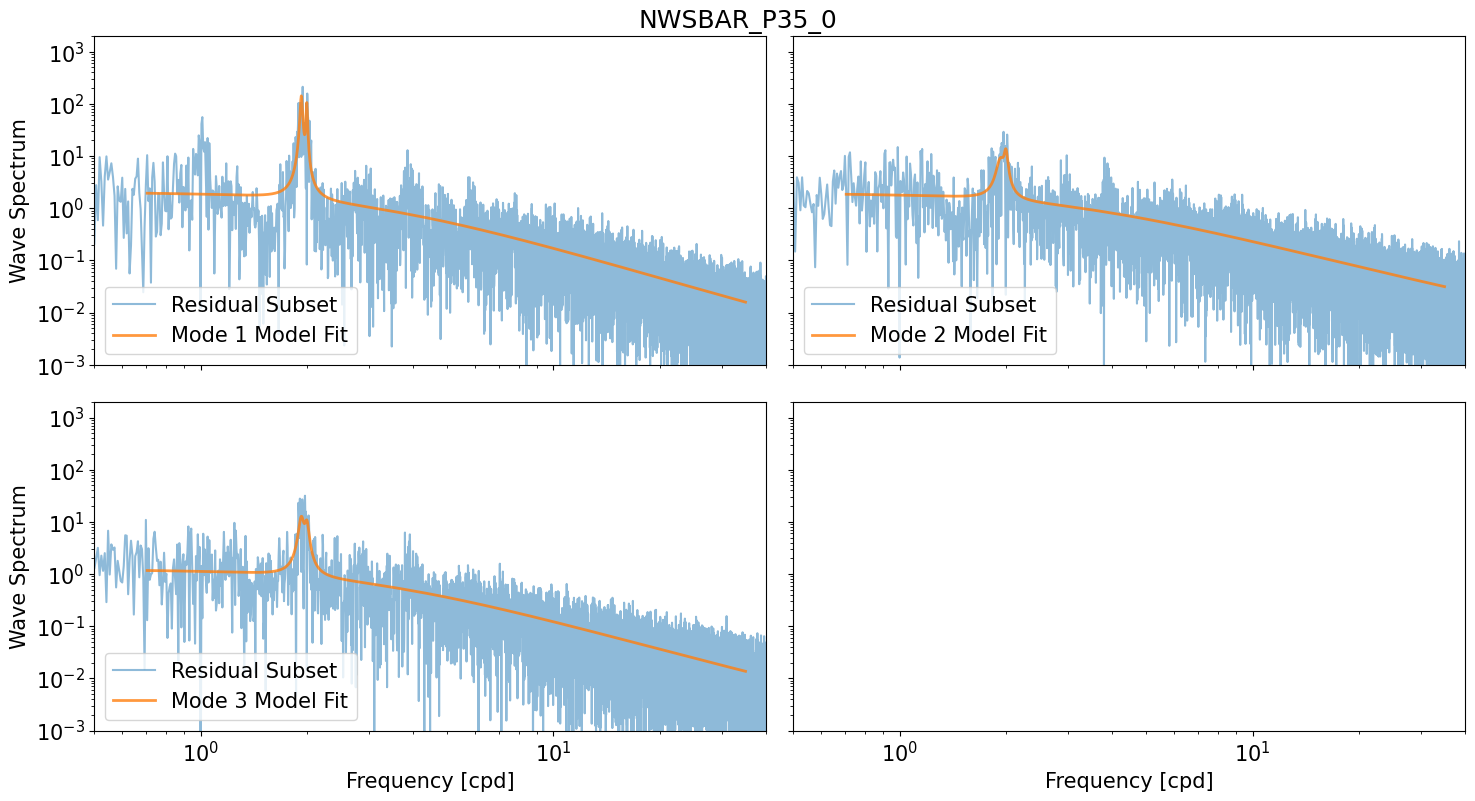

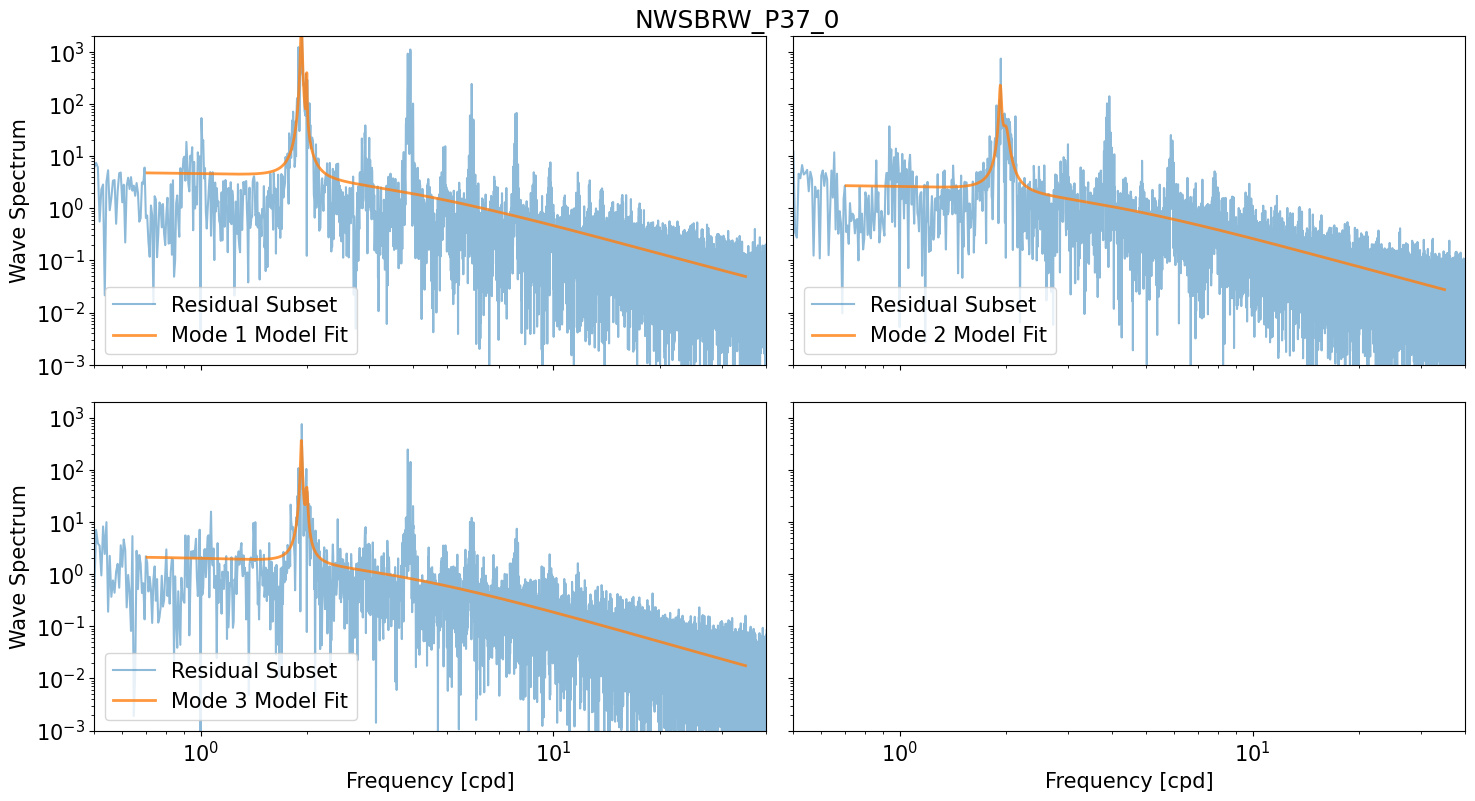

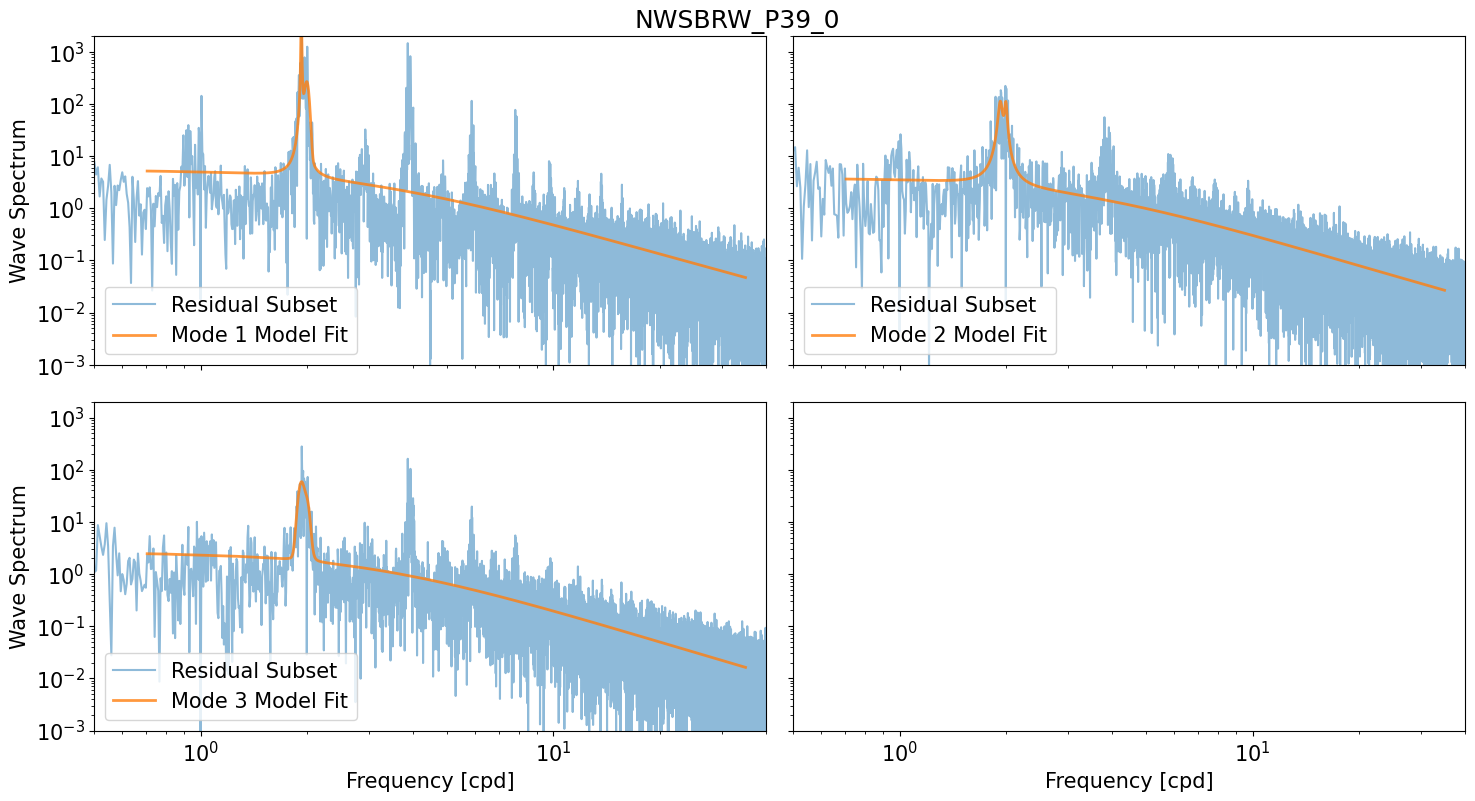

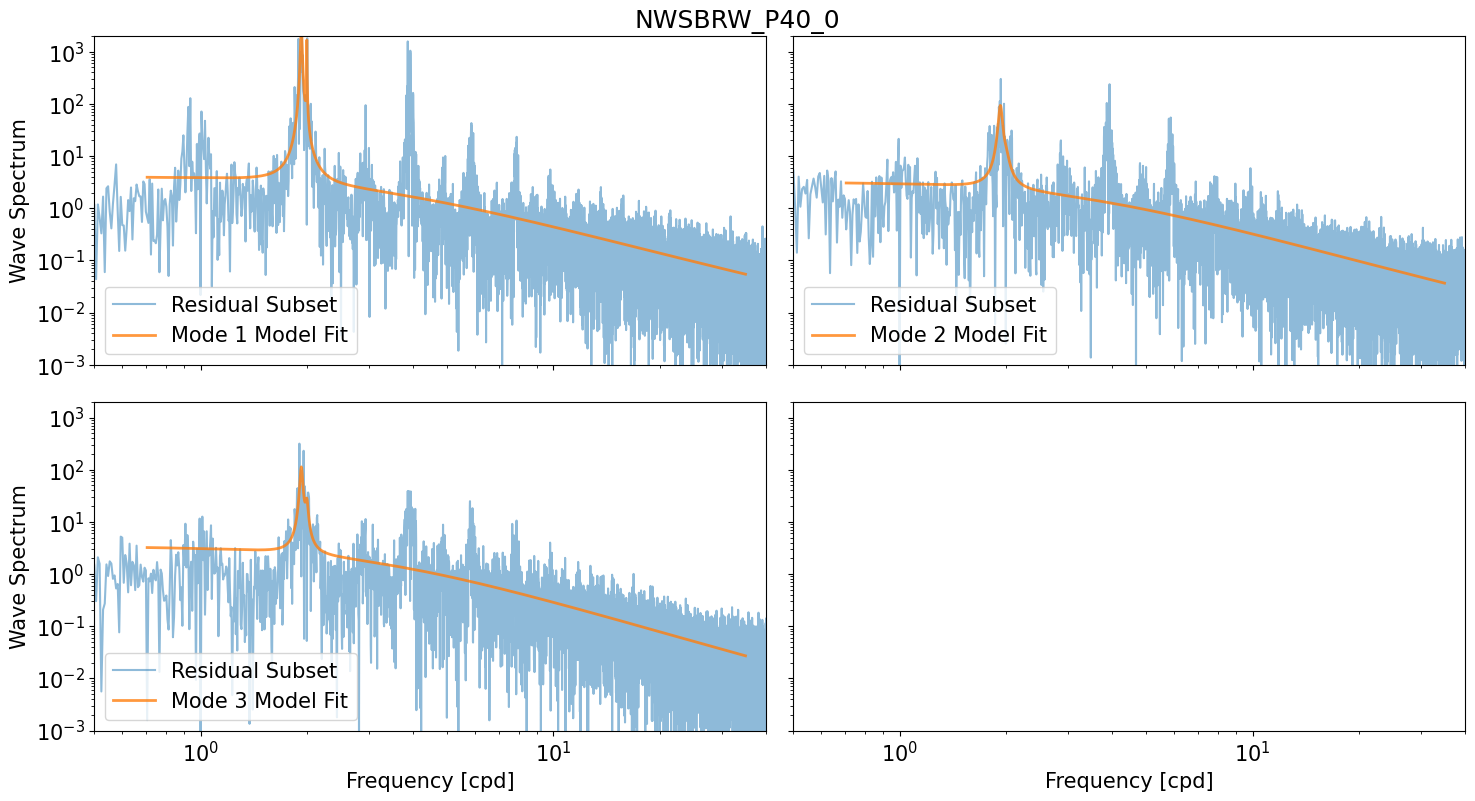

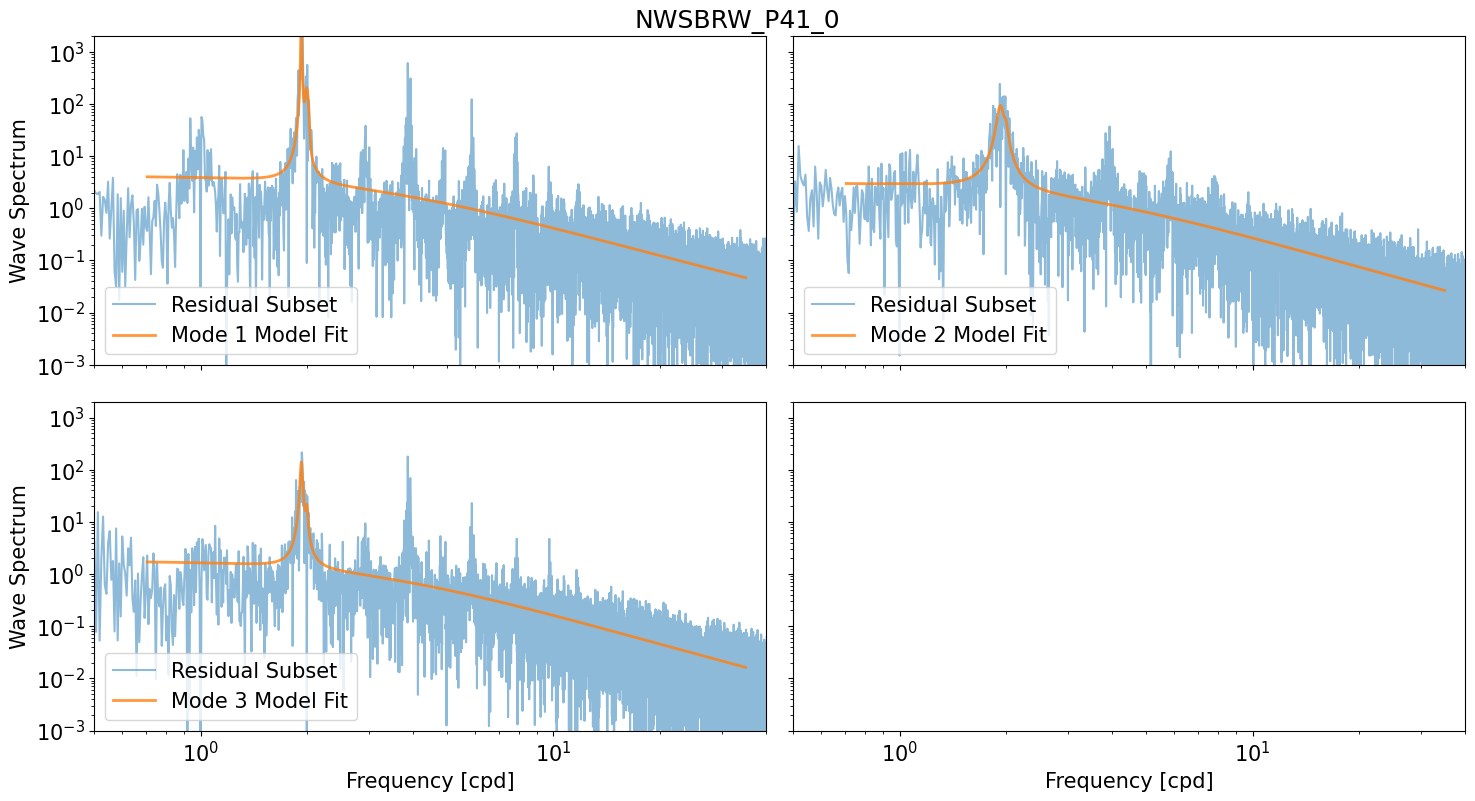

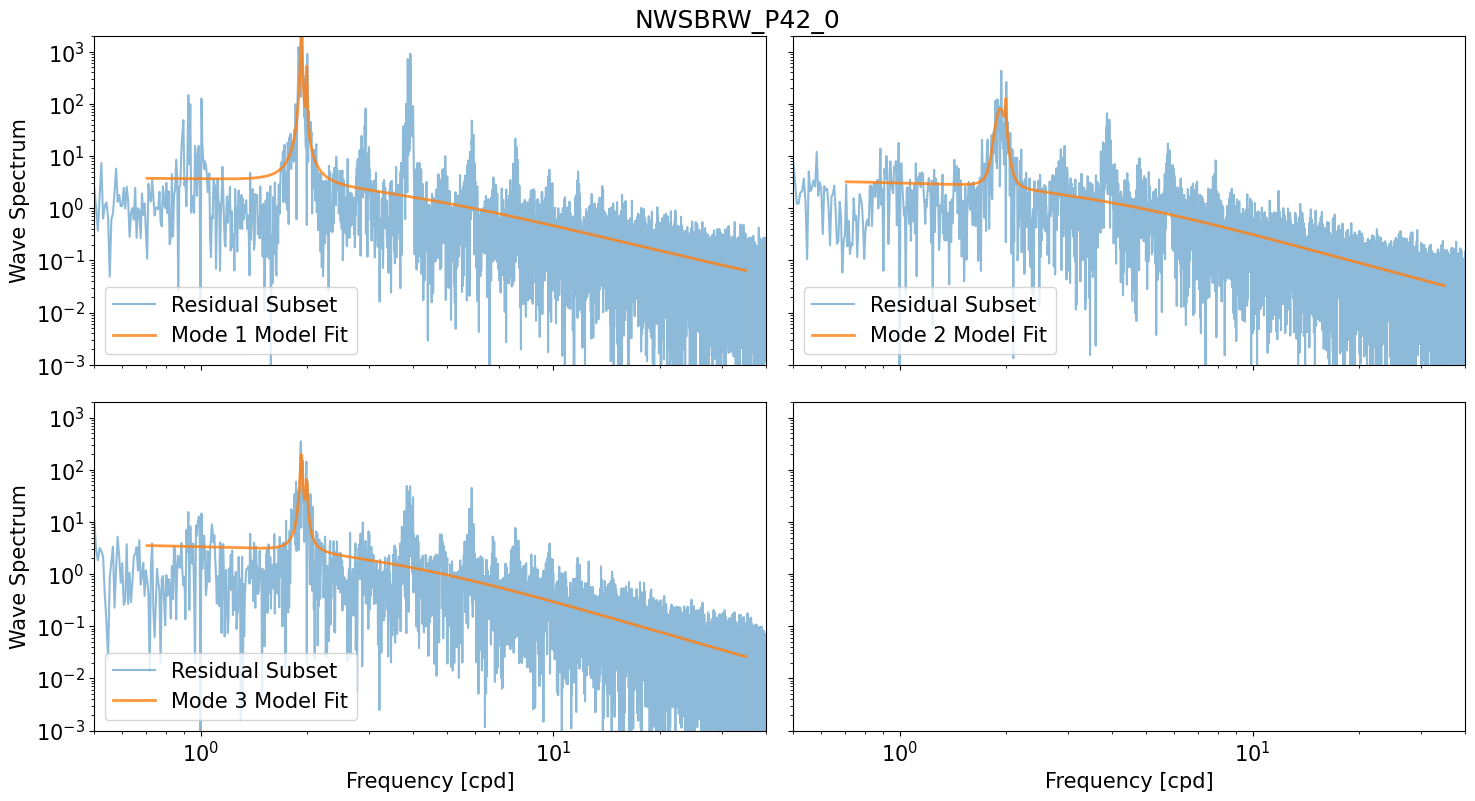

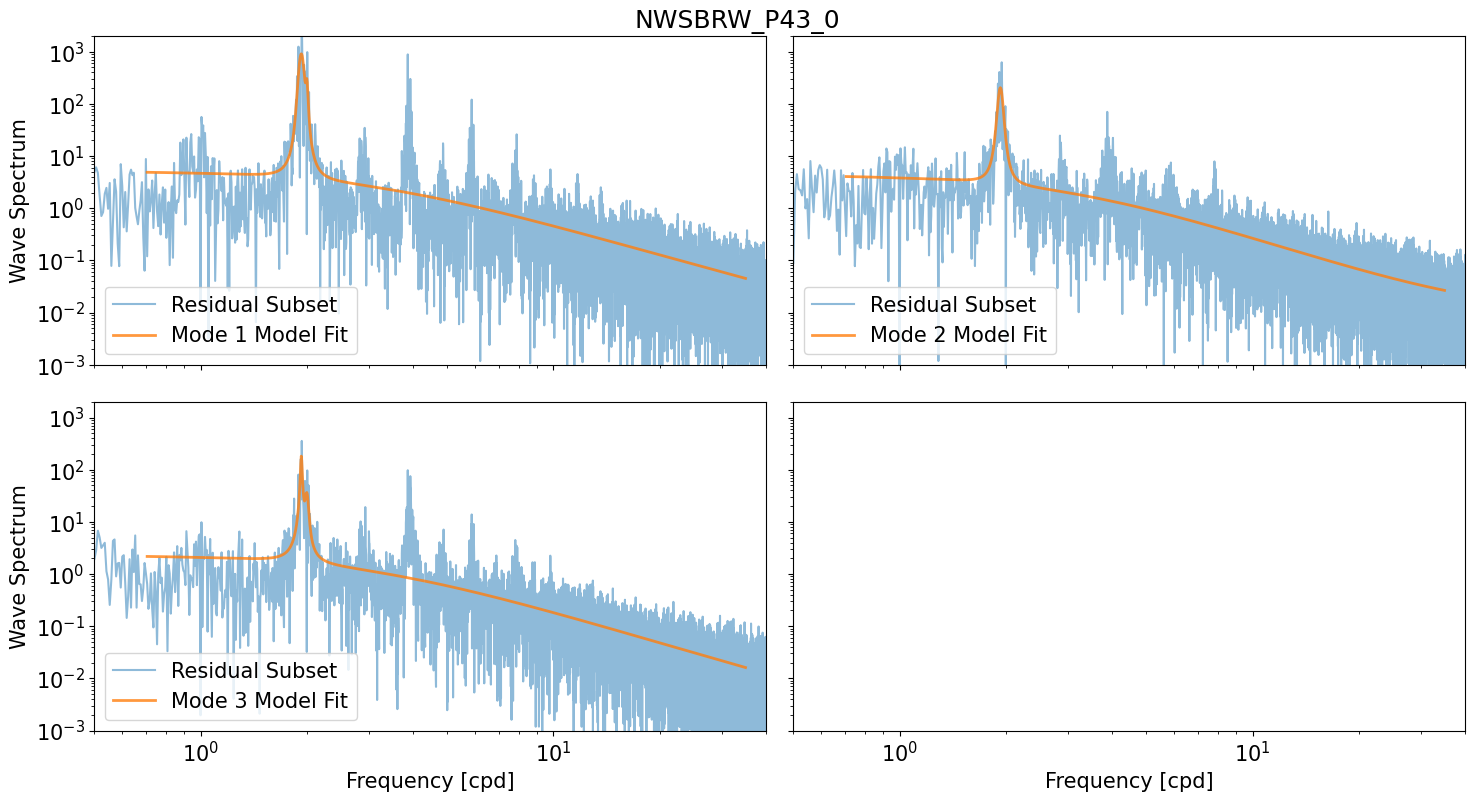

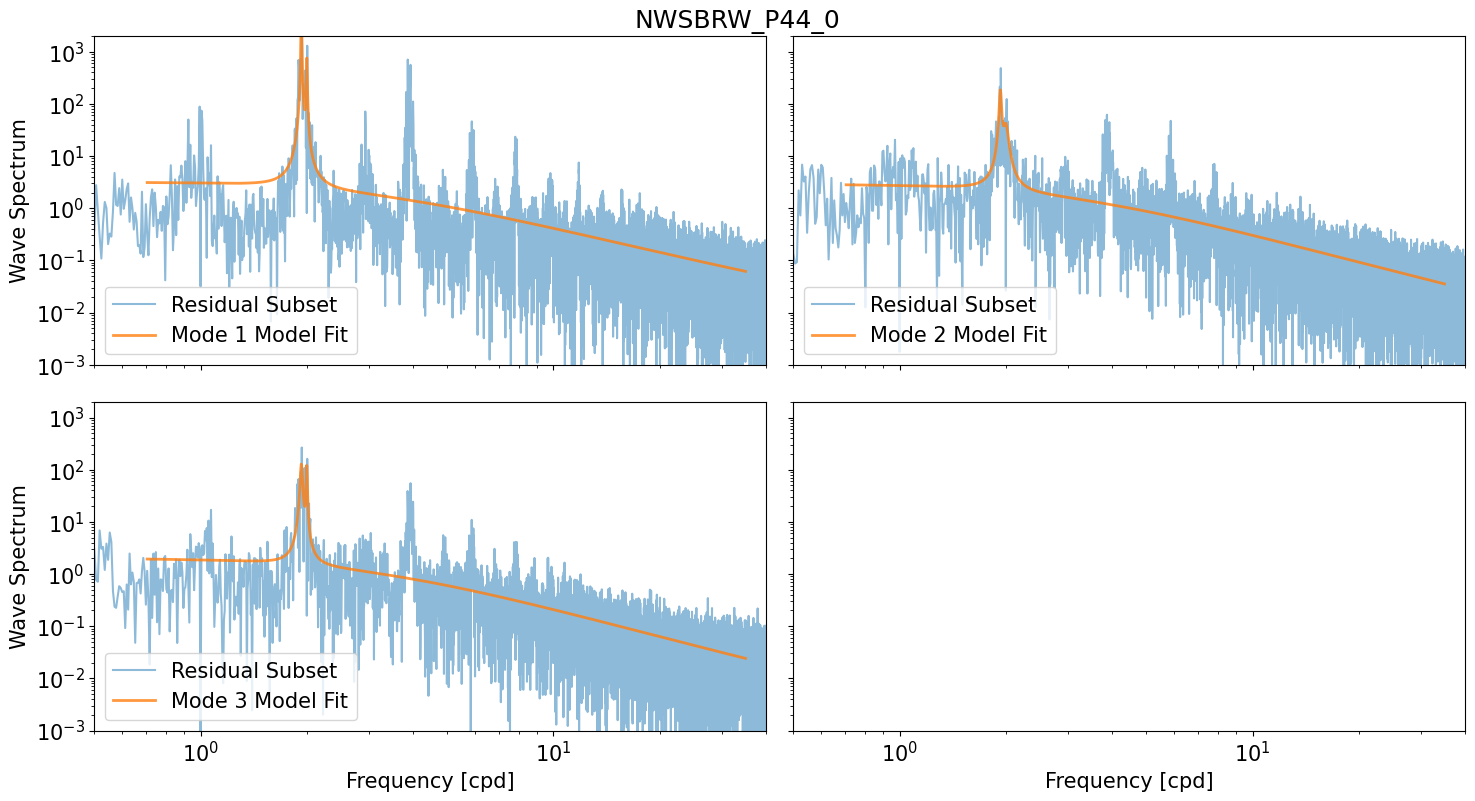

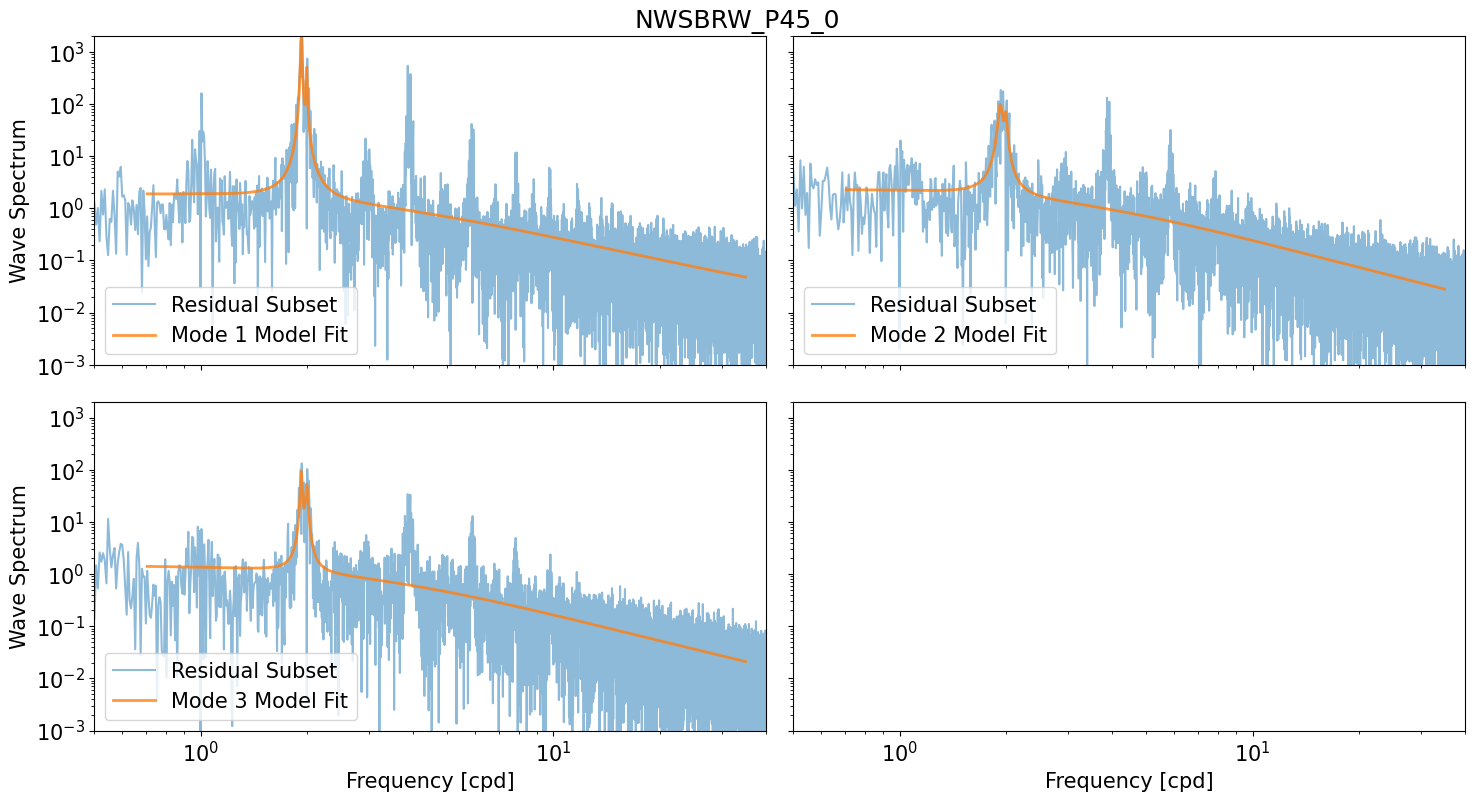

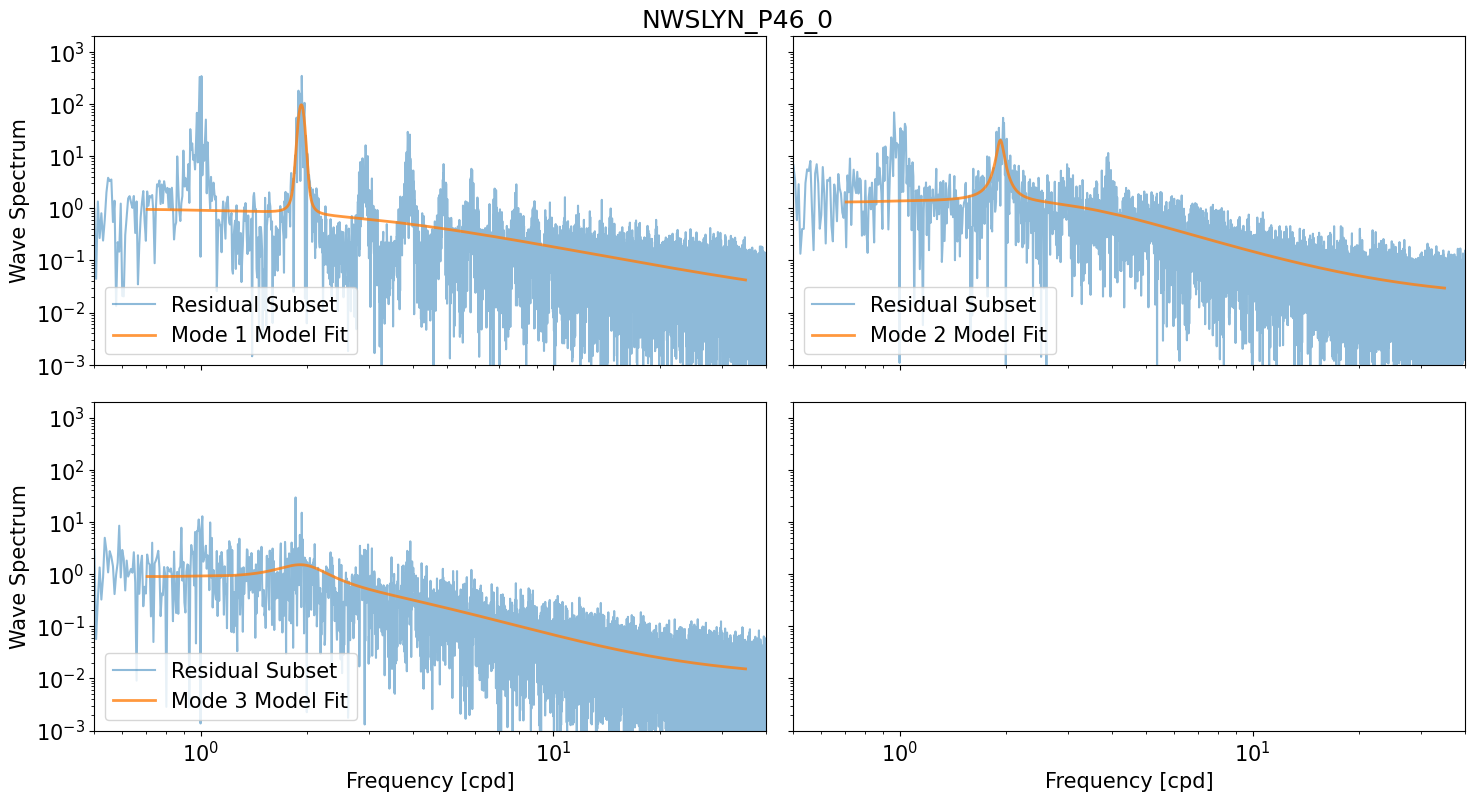

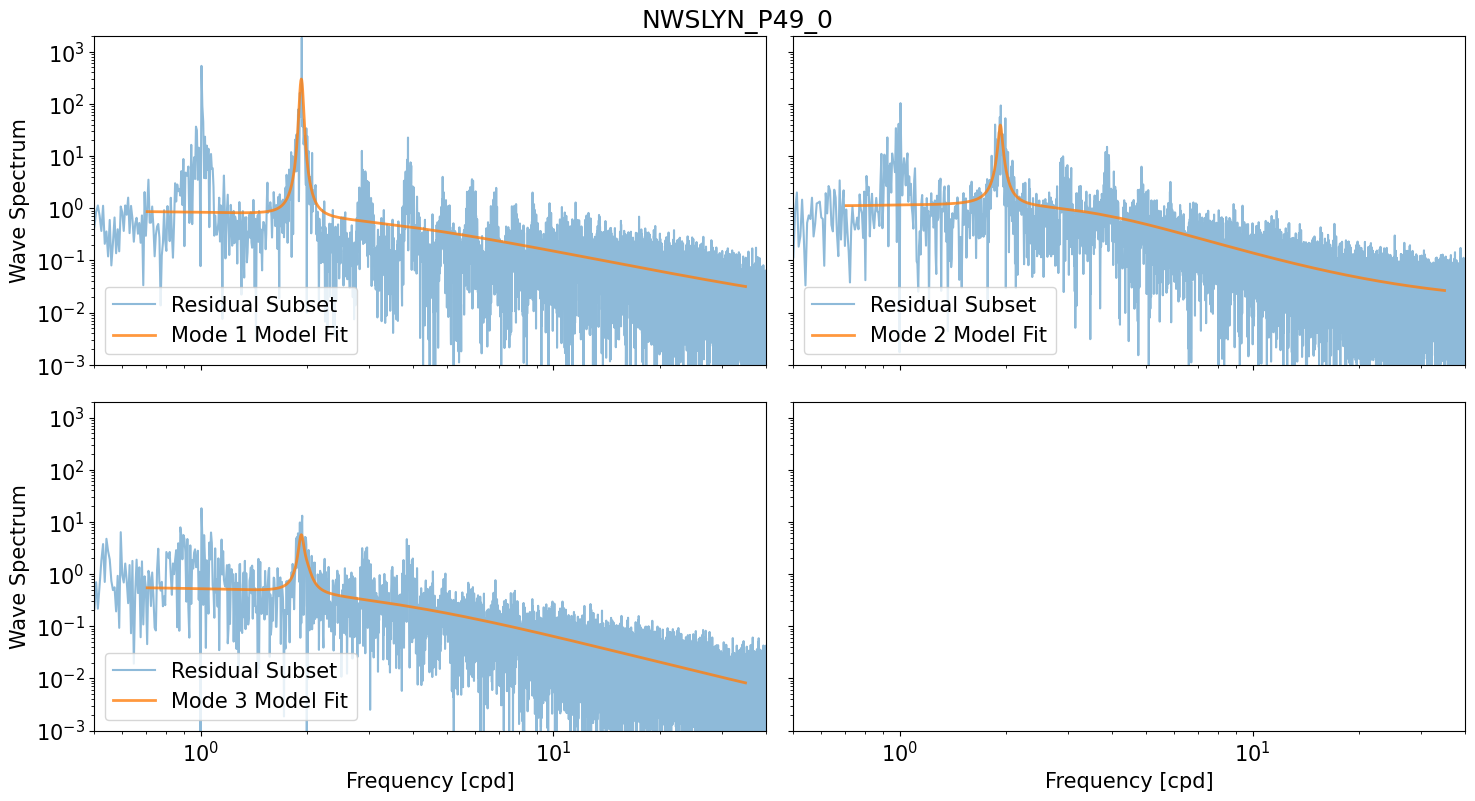

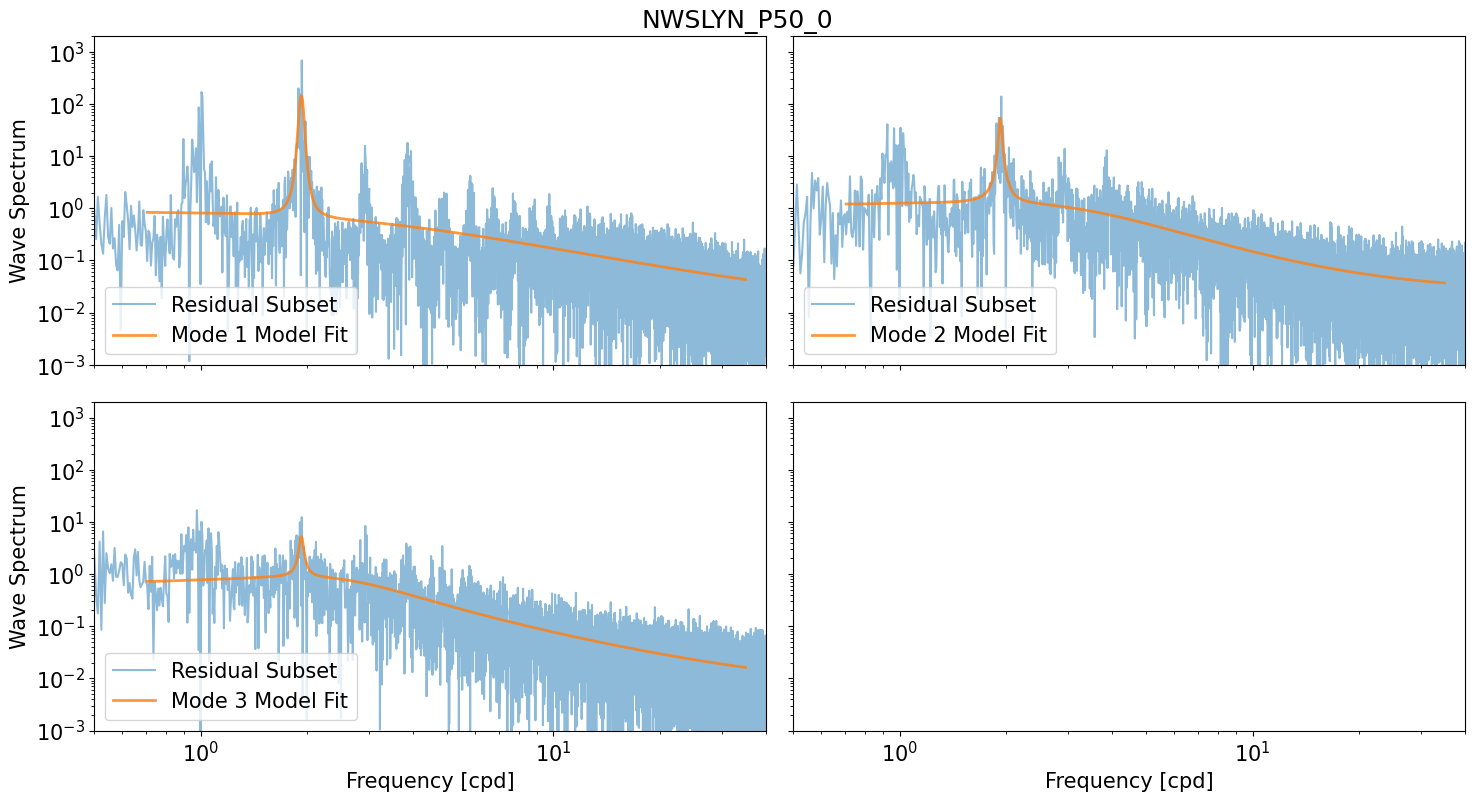

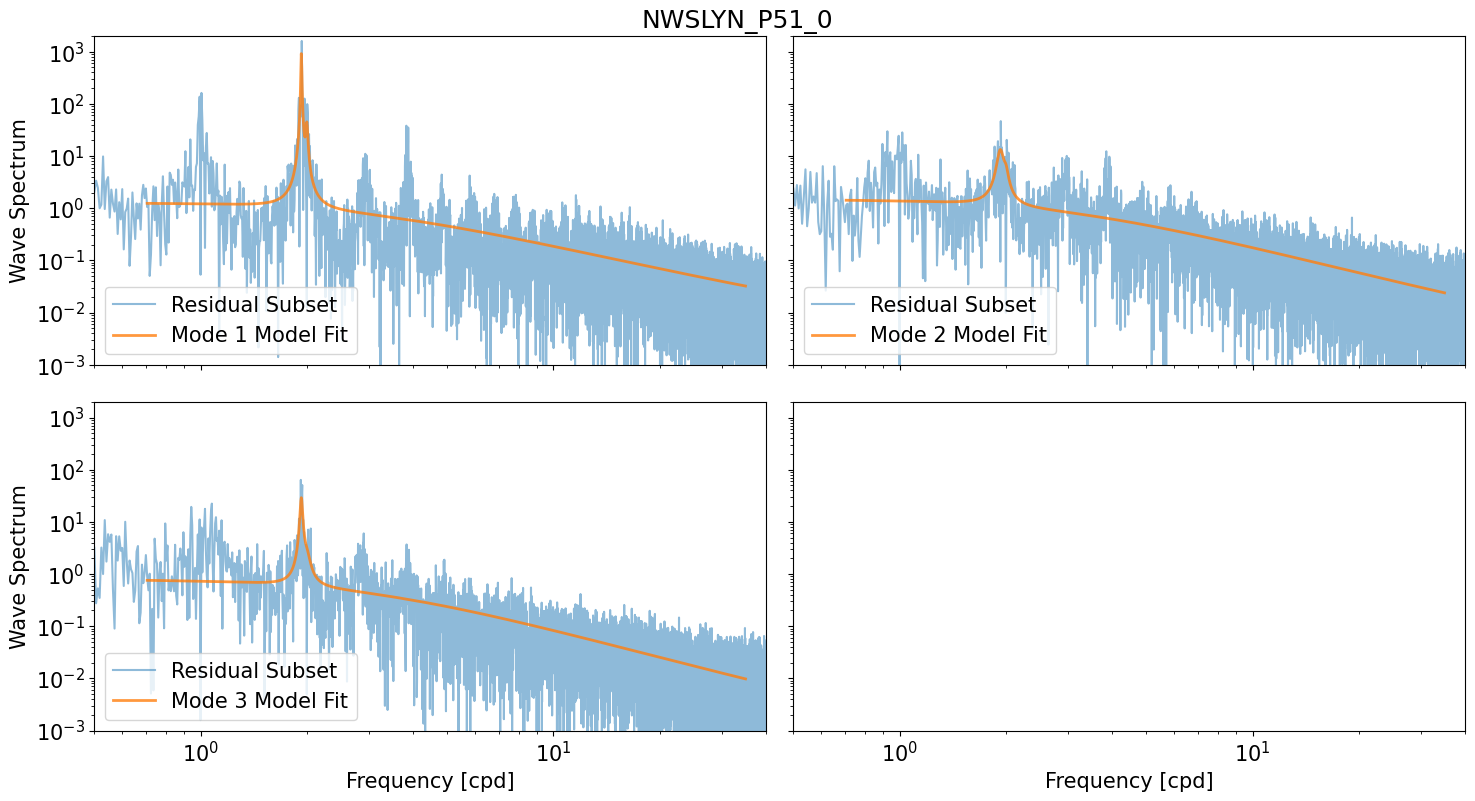

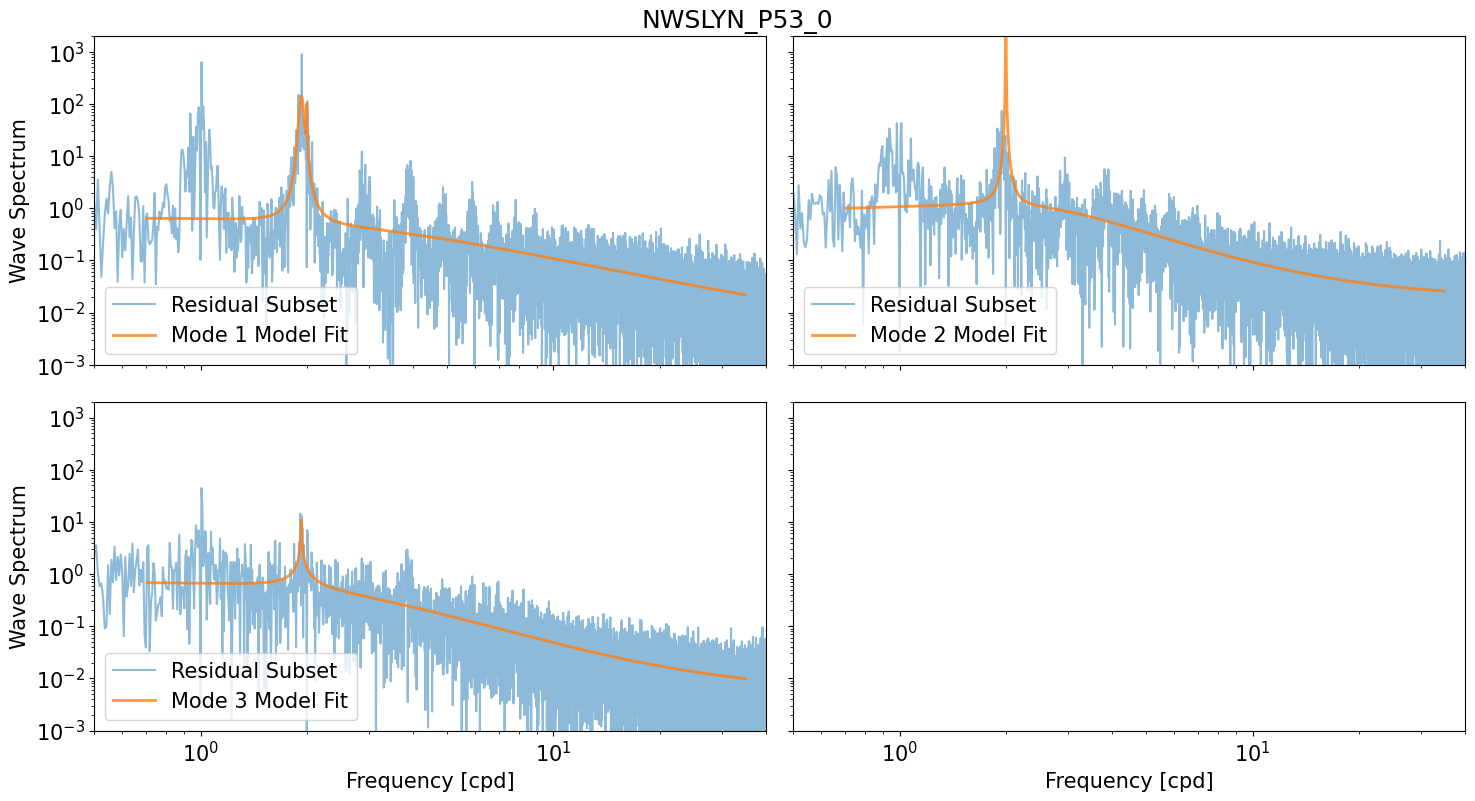

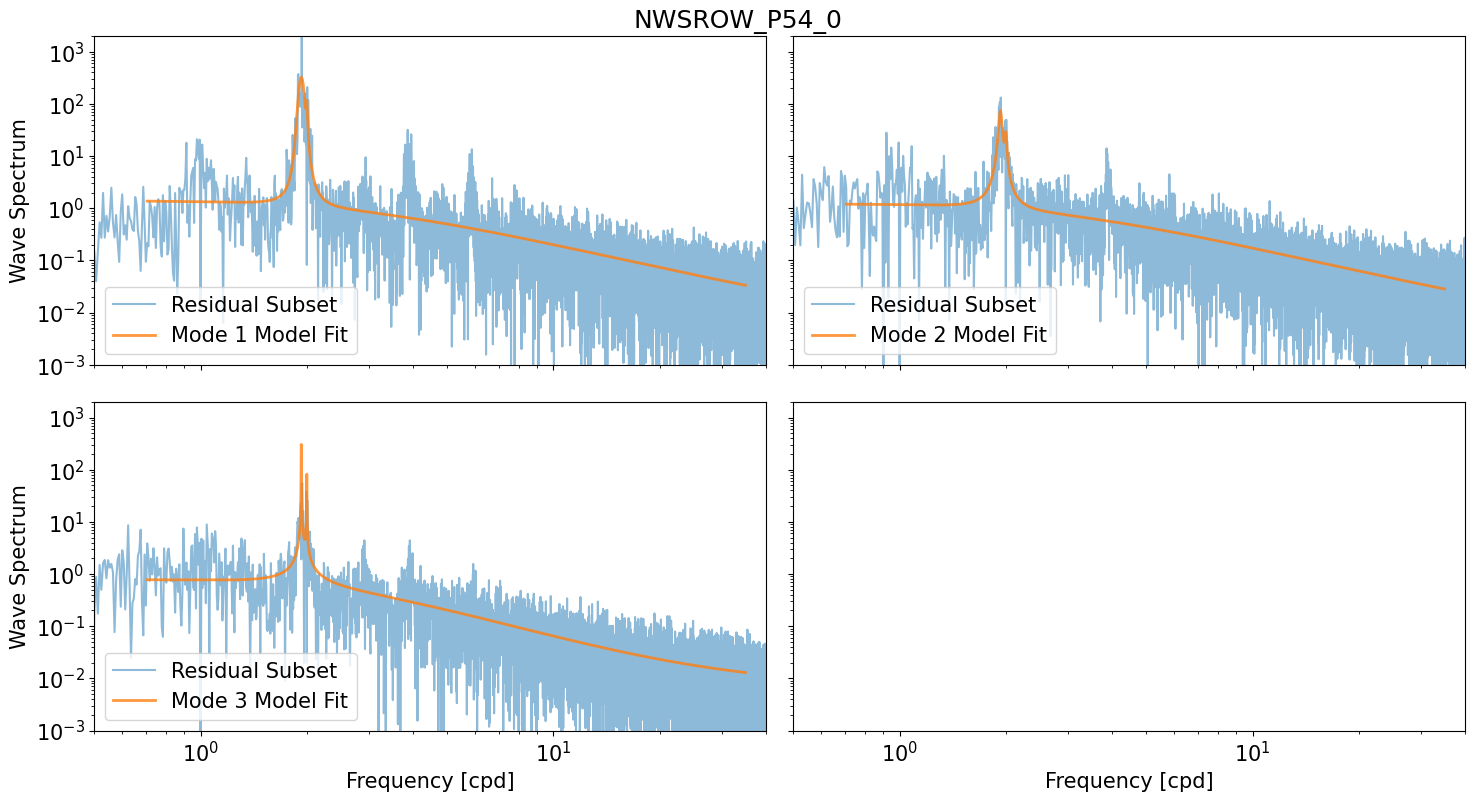

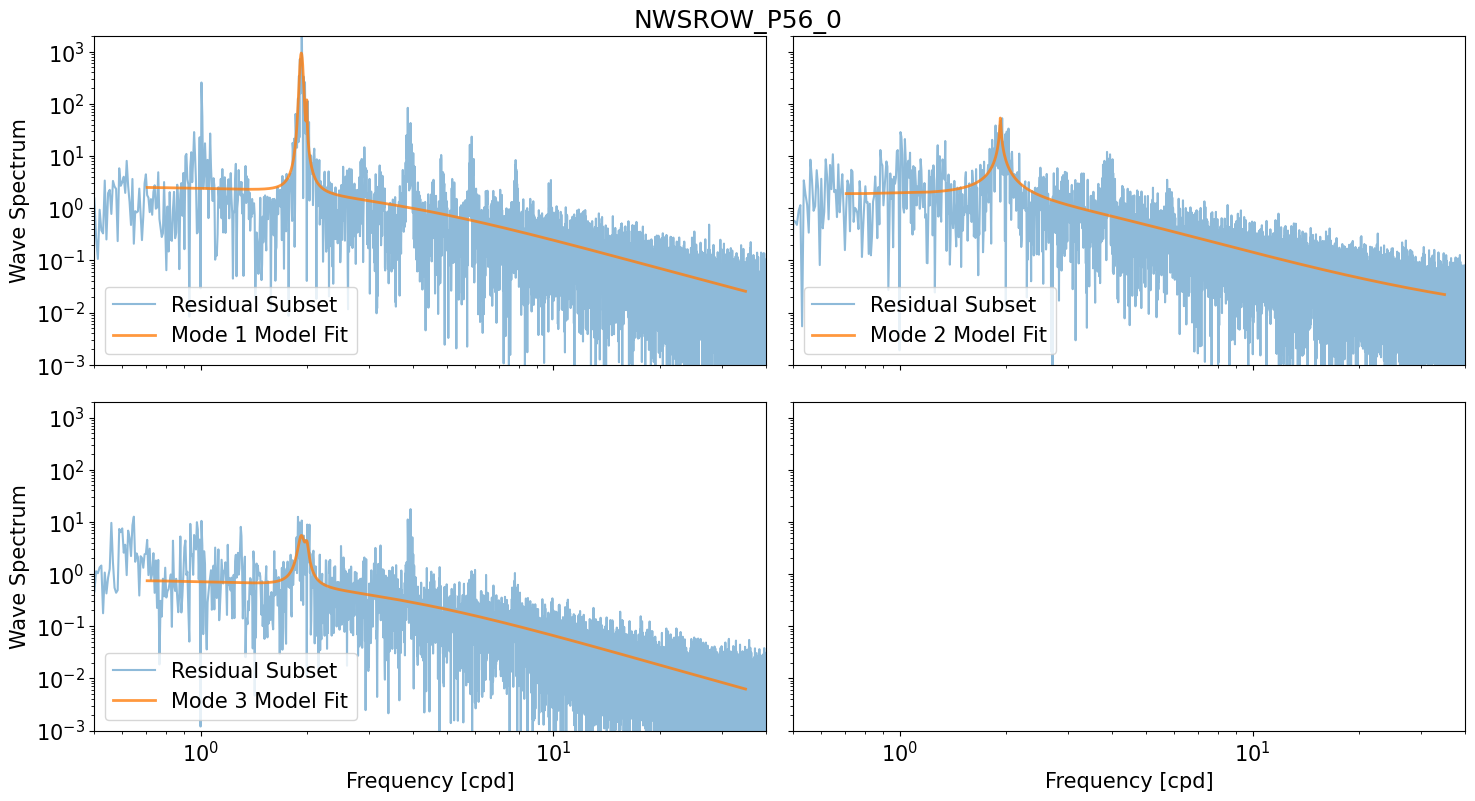

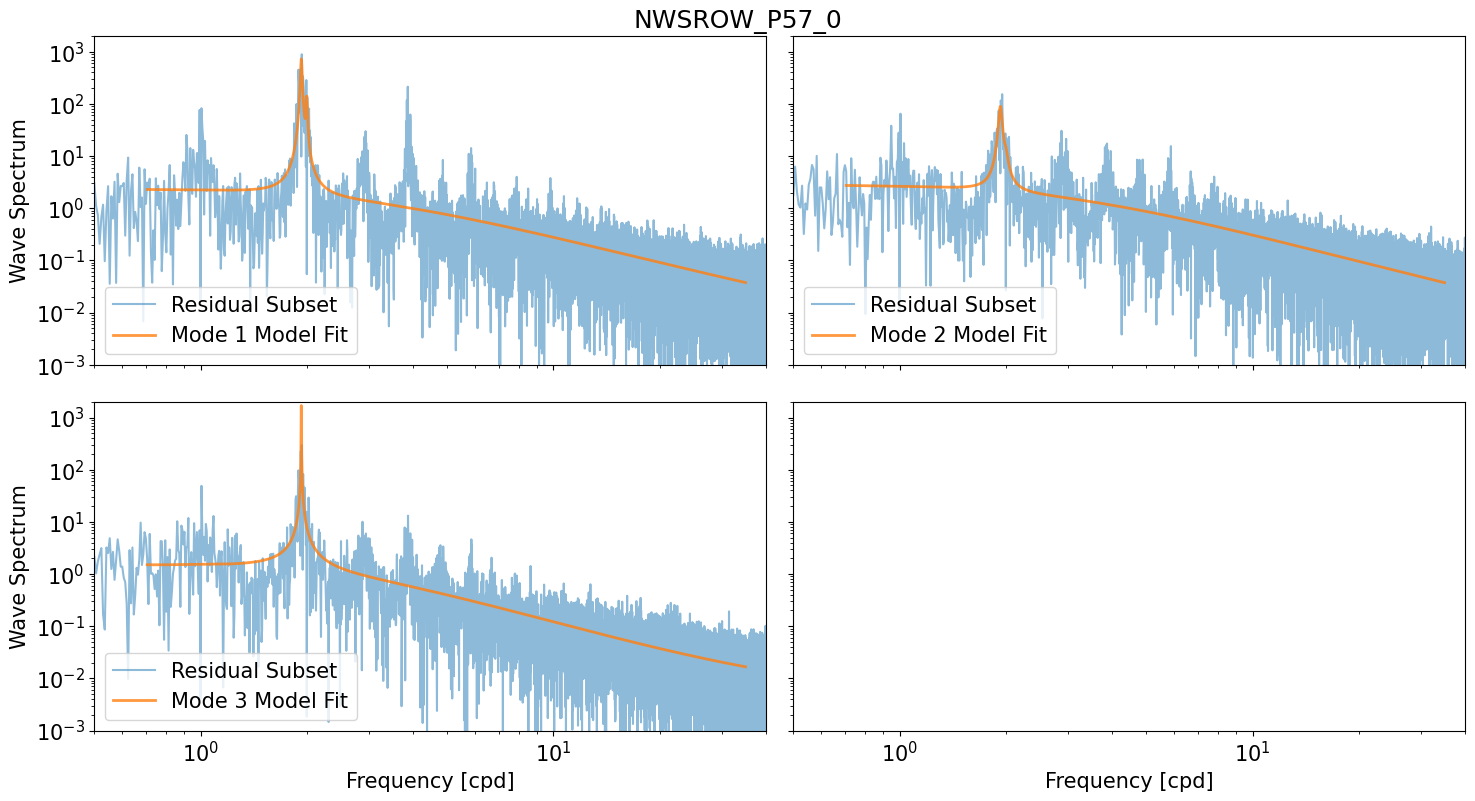

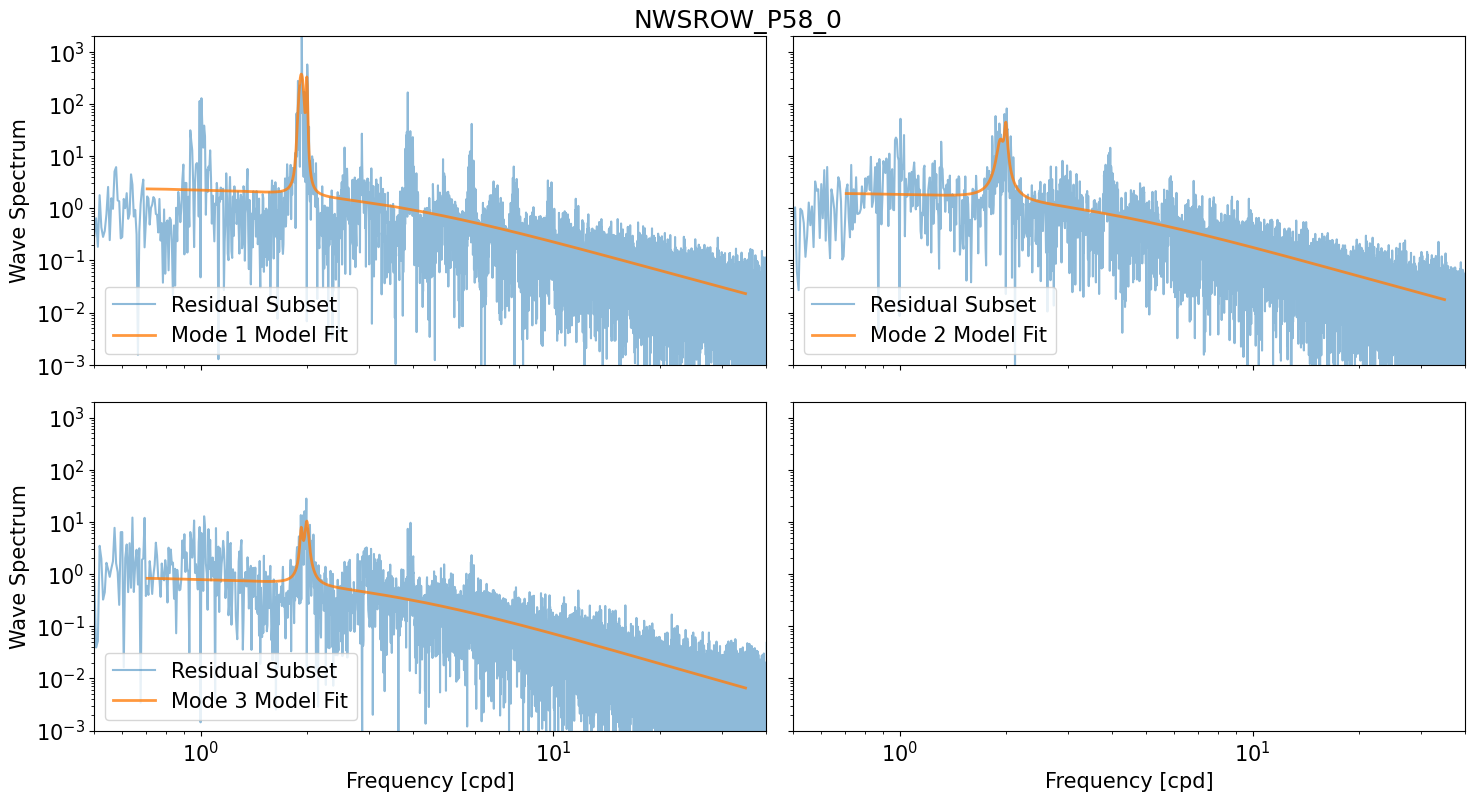

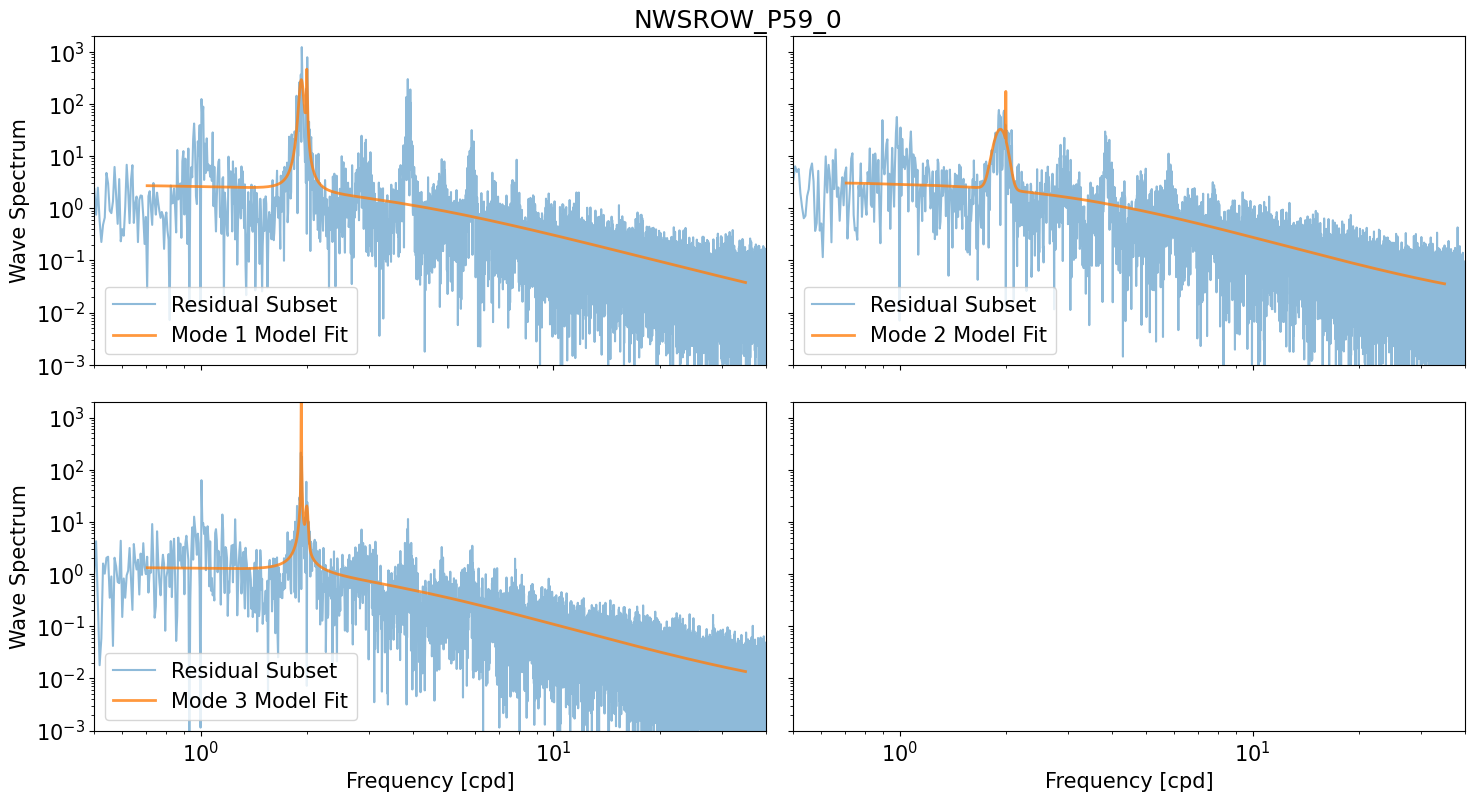

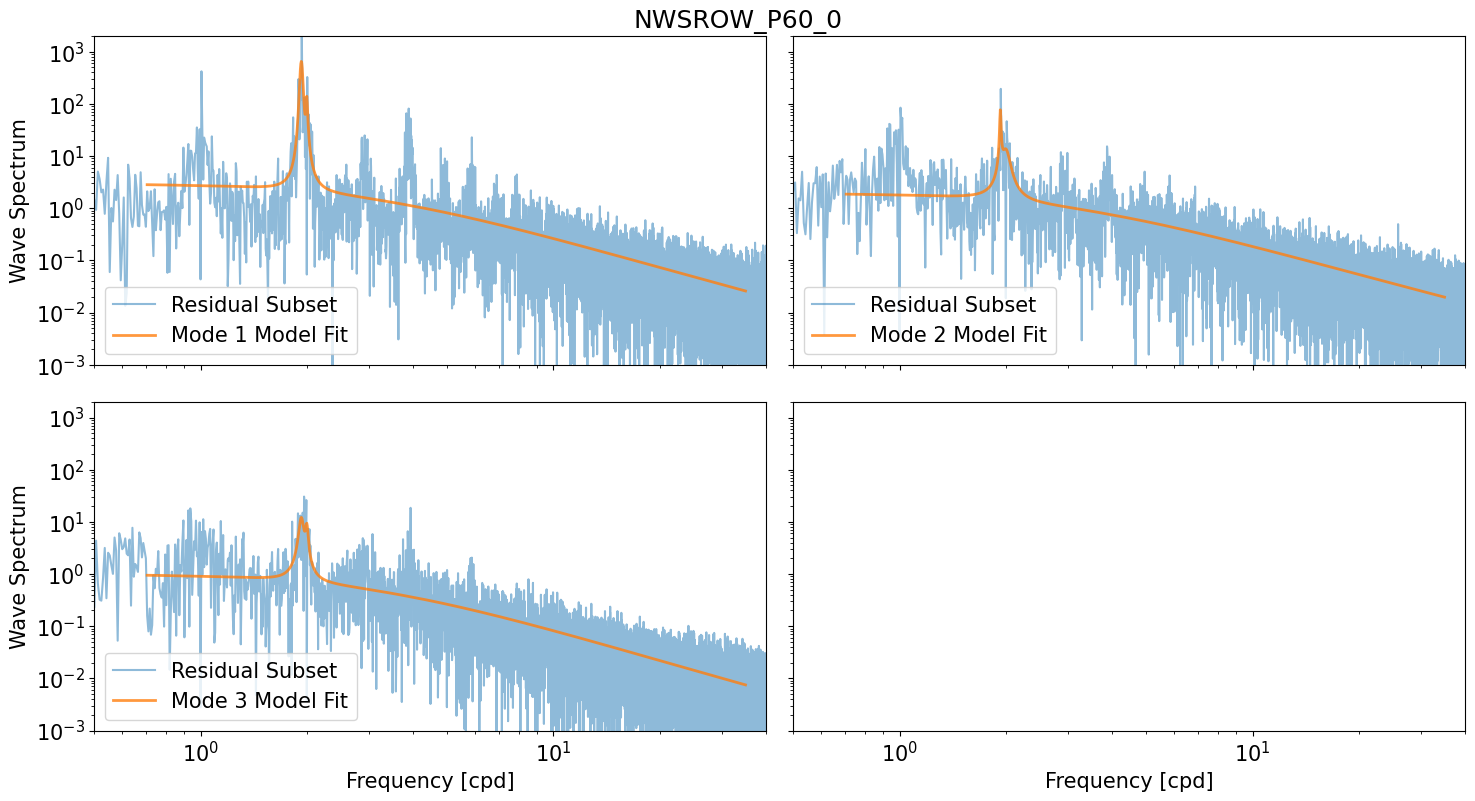

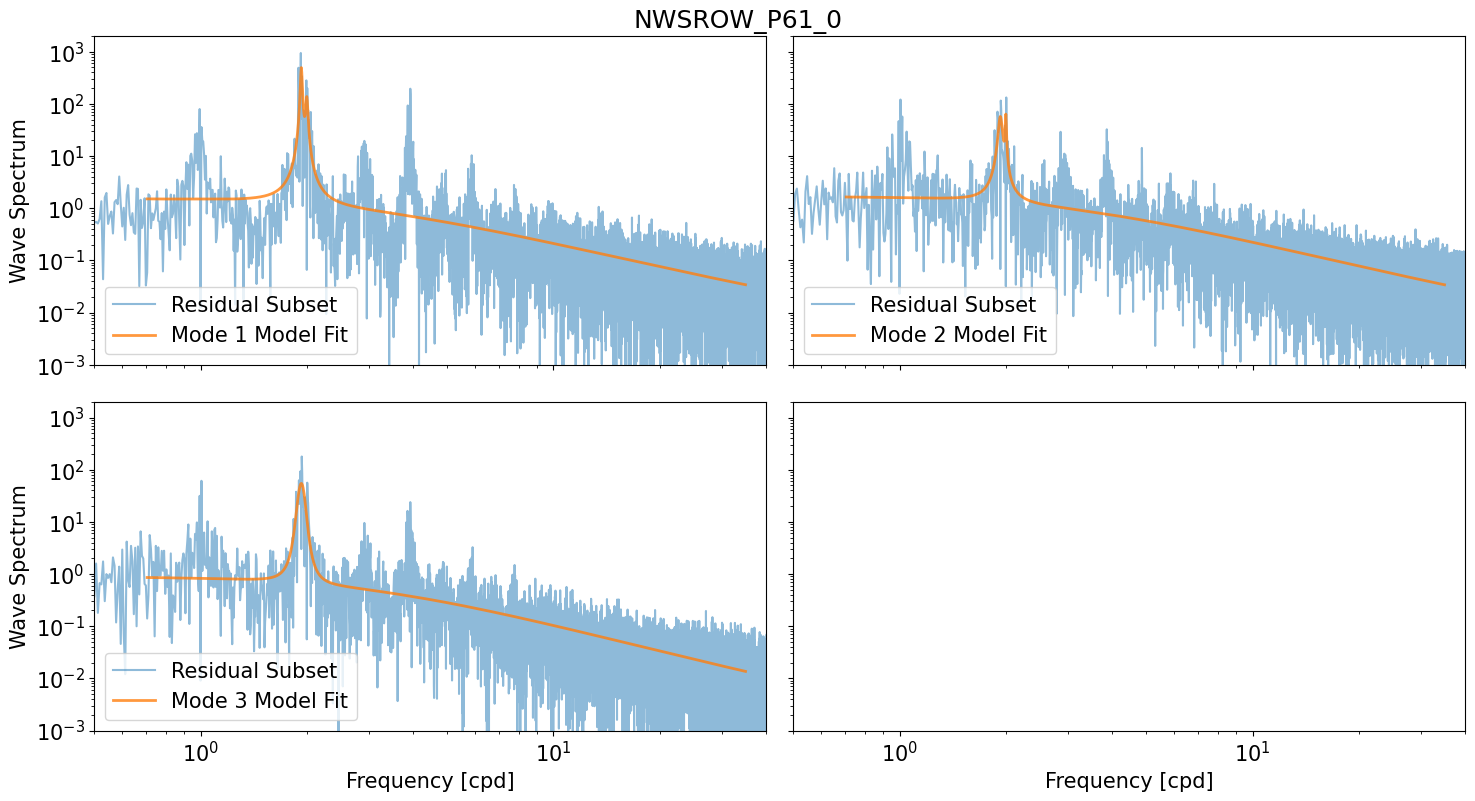

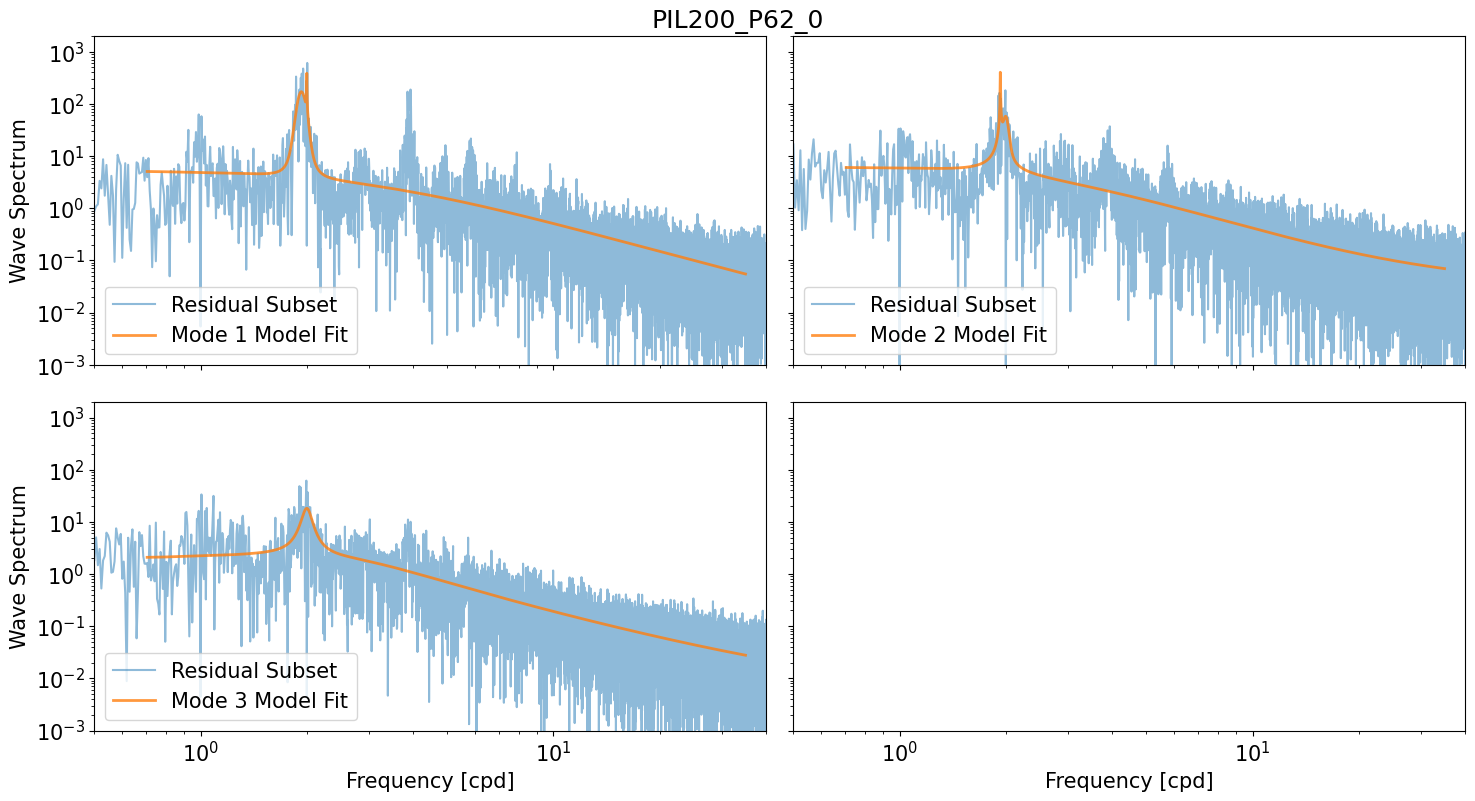

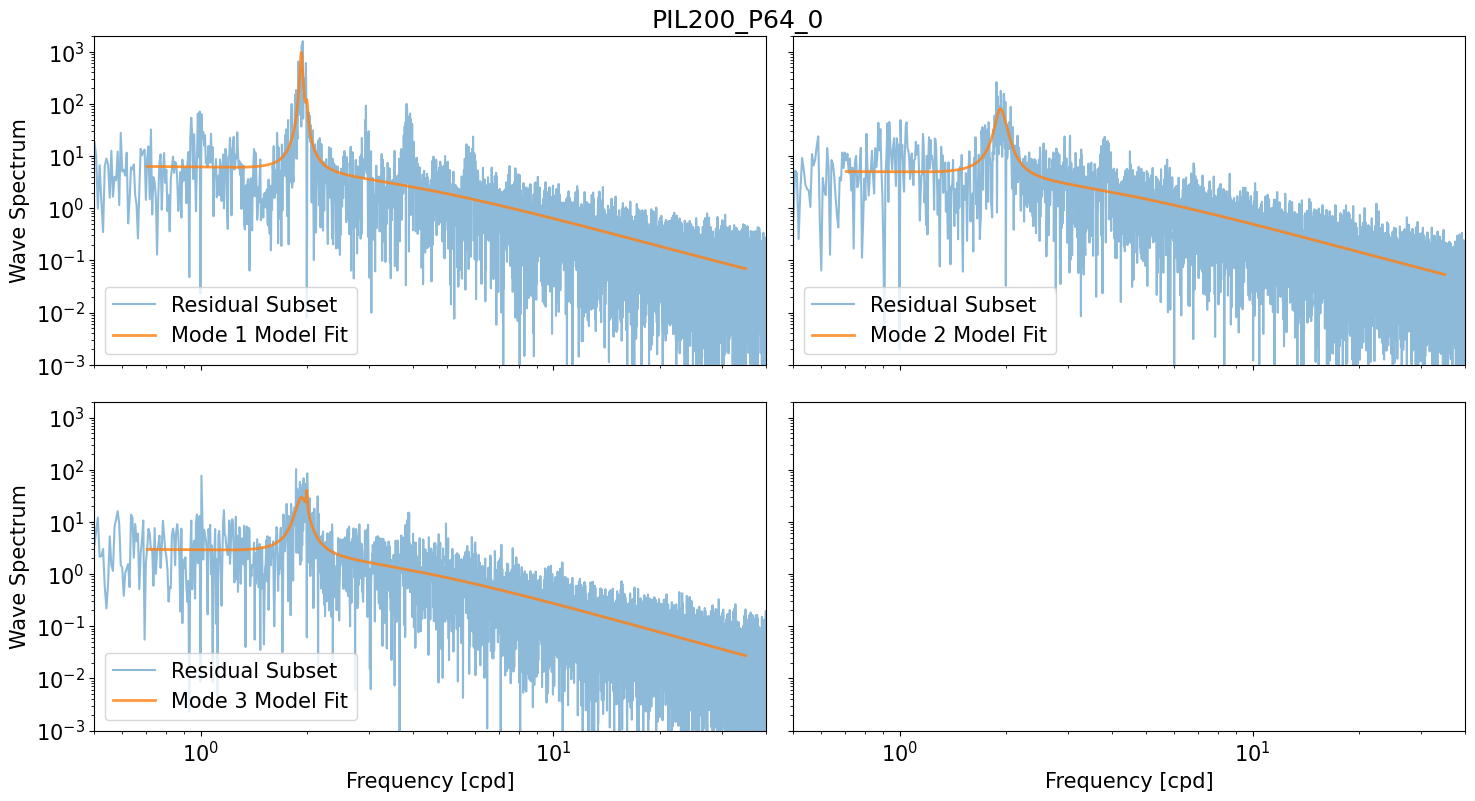

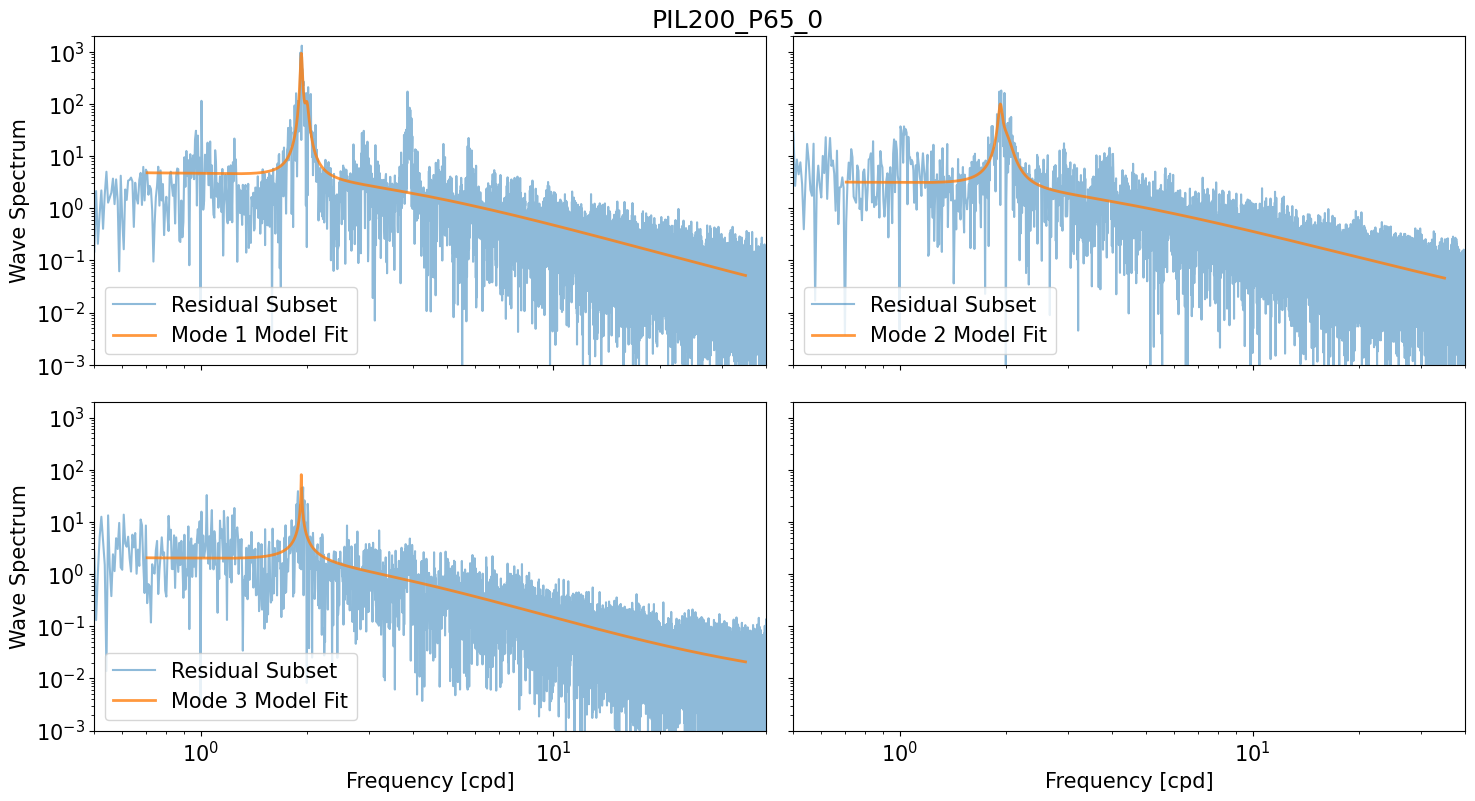

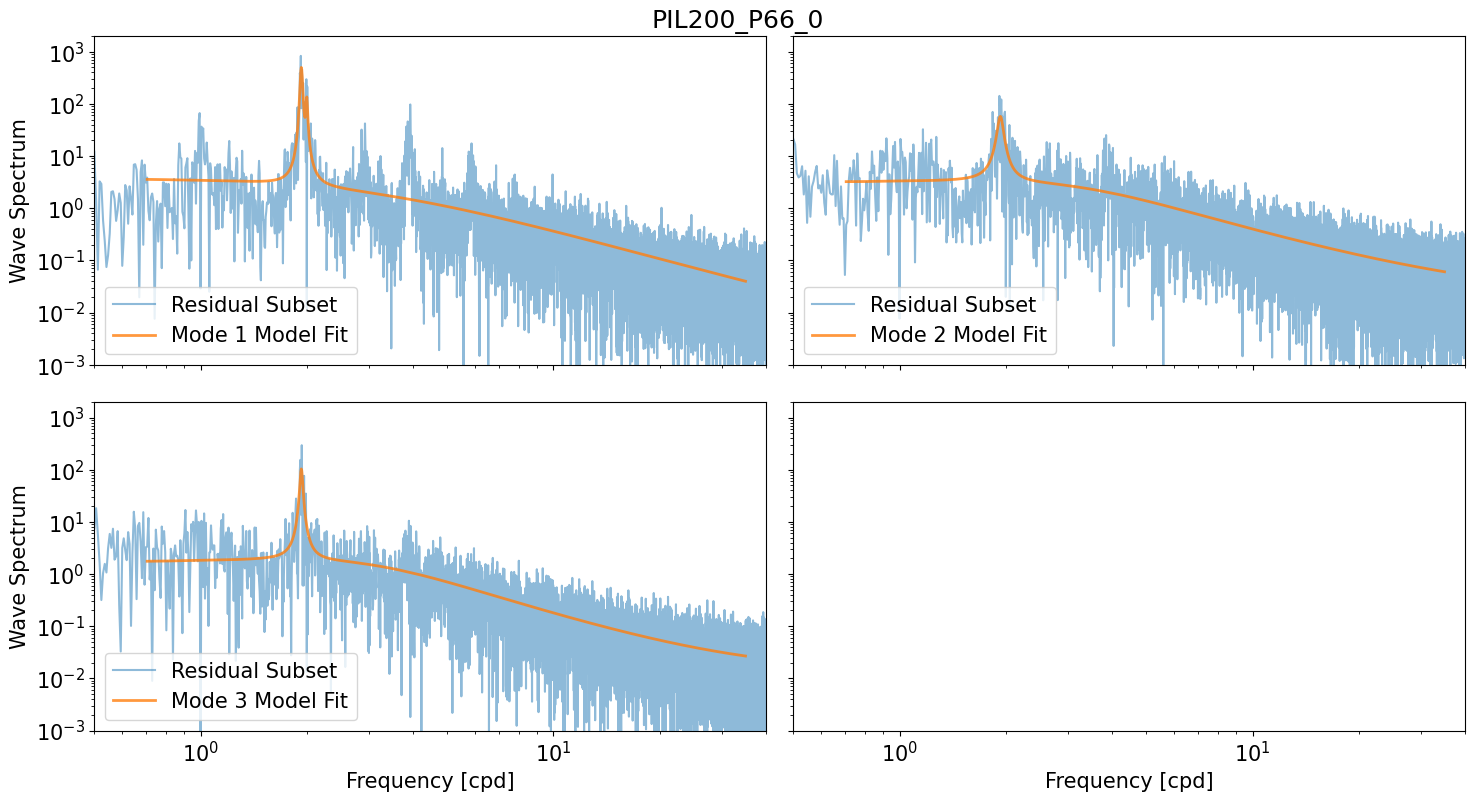

In [60]:
importlib.reload(Plot_figure)
Var_model_fit_dict = {}
plt.rcParams['figure.figsize'] = [15, 8]
for i in F_model_fit_dict_M1P2:
    Var_model_fit_dict[i] = Processing.Cal_var_from_Periodogram(F_model_fit_dict_M1P2[i],P_model_fit_dict_M1P2[i])
    fig, axes = Plot_figure.Model_fit_result(F_ε_dict[i],Puu_ε_dict[i],
                                 F_model_fit_dict_M1P2[i],P_model_fit_dict_M1P2[i])
    fig.suptitle(i, x=0.5, y=0.99, ha='center', va='center')   

In [61]:
importlib.reload(Processing)
Final_df_all_M1P2 = Processing.Construct_soln_df_from_dict(Start_date_dict,HA_var_dict,HA_M2_var_dict,HA_S2_var_dict, Var_residual_dict,
                                                      Var_model_fit_dict,Soln_model_fit_dict_M1P2,Whittle_dict_M1P2,M1P2_2_parameter_name)
Final_df_all_M1P2.to_csv('Final M1P2 Model fit parameters from displacement mode_3 - density fit - single_tanh - Longer HA.csv', index=False)
Final_df_all_M1P2

,Dict_name,Site,Mode,HA_var,HA_M2_var,HA_S2_var,Start_date,Var_residual,Var_model_fit,Whittle_value,η_c,α_c,η_S2,τ_S2,γ_S2,η_M2,τ_M2,γ_M2,season
0,KIM200_P17_0,KIM200,0,62.851913,28.257372,29.074344,2012-02-02,55.163108,55.469570,-5609.327480,5.330525,0.909499,2.171195e+00,1.296714e+01,0.989021,5.635535,20.641881,0.998551,Feb-Apr
1,KIM200_P17_0,KIM200,1,2.455337,1.442767,0.112712,2012-02-02,36.159441,35.631723,-5942.047607,5.355850,0.945773,2.384010e+00,7.741292e+00,0.996541,3.271375,7.956410,1.003332,Feb-Apr
2,KIM200_P17_0,KIM200,2,1.482712,1.042420,0.152461,2012-02-02,13.047133,13.215208,-10239.124682,3.644836,1.177772,9.858386e-01,1.428149e+01,1.340781,2.355277,0.108908,0.206880,Feb-Apr
3,KIM200_P19_0,KIM200,0,69.967877,48.370311,18.934609,2013-01-27,52.817096,53.337145,-5952.444568,5.407425,0.957979,1.928340e+00,1.097283e+01,0.994737,5.477143,17.022566,0.997385,Feb-Apr
4,KIM200_P19_0,KIM200,1,4.068388,0.696105,2.853342,2013-01-27,50.758085,50.651237,-5396.578295,5.956438,1.013495,3.285965e+00,3.787774e+00,0.997736,4.037279,4.344321,0.997739,Feb-Apr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,PIL200_P65_0,PIL200,1,3.437703,1.886823,1.041114,2013-08-03,48.162080,47.328073,-3890.155027,6.011849,0.881368,3.115869e+00,1.840768e+00,0.996967,3.721192,6.492538,0.997527,Aug-Oct
104,PIL200_P65_0,PIL200,2,1.098996,0.642273,0.306065,2013-08-03,18.207319,18.974584,-8744.616886,3.810972,1.161448,4.495998e-09,1.399987e-30,1.421611,3.512306,0.798025,0.260396,Aug-Oct
105,PIL200_P66_0,PIL200,0,48.034713,44.695713,1.878823,2014-02-11,73.559495,74.455948,-4184.619288,6.200816,0.935889,3.023757e+00,1.381401e+01,0.861721,6.284209,14.411491,1.279631,Feb-Apr
106,PIL200_P66_0,PIL200,1,2.535063,1.931789,0.206018,2014-02-11,45.043918,44.451647,-3034.492514,3.413751,0.589537,6.007731e+00,6.191274e-02,0.998404,3.661827,4.153348,0.996426,Feb-Apr


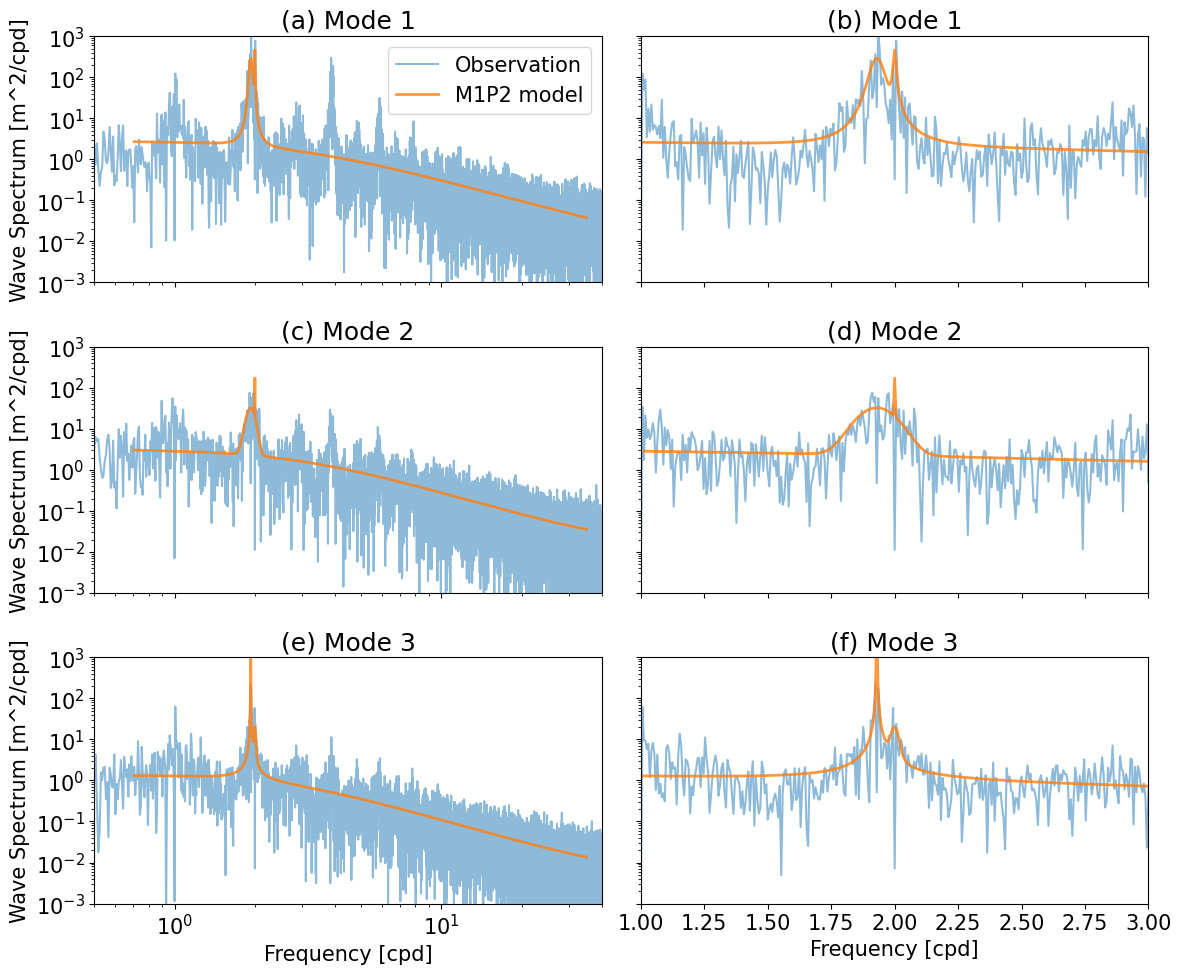

In [66]:
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import string
example_name = "NWSROW_P59_0"
num_subplots = 6  # 3x2 = 6 subplots
cols = 2  # 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharey='row',sharex='col')
axes = axes.flatten()
figure_order = list(string.ascii_lowercase)  # ['a', 'b', 'c', ..., 'z']
for i in range(num_subplots):
    ax = axes[i]
    if i % 2 == 0:  # left column
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5, label='Observation')
        ax.plot(F_model_fit_dict_M1P2[example_name][i//2], P_model_fit_dict_M1P2[example_name][i//2], linewidth=2, alpha=0.8, label='M1P2 model')
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(0.5, 40)
        ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    else:
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5)
        ax.plot(F_model_fit_dict_M1P2[example_name][i//2], P_model_fit_dict_M1P2[example_name][i//2], linewidth=2, alpha=0.8)
        ax.set_xlim(1, 3)
        ax.set_yscale("log")
    ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    ax.set_ylim(1e-3, 1e3)
# Axis labels
for i in range(num_subplots):
    if i // 2 == 2:  # bottom row
        axes[i].set_xlabel('Frequency [cpd]')
    if i % 2 == 0:  # left column 
        axes[i].set_ylabel('Wave Spectrum [m^2/cpd]')
axes[0].legend(loc='upper right')  # legend only on 
plt.tight_layout()
plt.savefig('M1P2_model_fit_results_at_NWSROW.pdf')
plt.show()

In [67]:
importlib.reload(Processing)
deep_sites = ['ITFTIS','KIM400'  ]
shallow_sites = ['NWSLYN','NWSBRW','KIM200','NWSROW','PIL200','NWSBAR',]
Final_df_M1P2_all = Final_df_all_M1P2
Final_df_M1P2_all = Processing.Select_df_from_sites(Final_df_M1P2_all,shallow_sites,'M1P2')
Final_df_M1P2_all['HA_η'] = np.sqrt(Final_df_M1P2_all['HA_var'])
Final_df_M1P2_all['HA_M2'] = np.sqrt(Final_df_M1P2_all['HA_M2_var'])
Final_df_M1P2_all['HA_S2'] = np.sqrt(Final_df_M1P2_all['HA_S2_var'])

In [68]:
from functions import Cov
importlib.reload(Cov)
importlib.reload(Processing)
#M1P2
# Final_df_M1P2_all = pd.read_csv('Final M1P2 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv')  
Drop_df_M1P2, Final_df_M1P2_clean = Processing.Clean_and_Process_DF(Final_df_M1P2_all,model_type = 'M1P2')

34 (31.48%) of 108 fits are removed


In [71]:
importlib.reload(Processing)
M1P2_parameter_name = ['Dict_name','η_c','α_c','η_S2','τ_S2','γ_S2','T_S2',
                       'η_M2','τ_M2','γ_M2','T_M2','Var_model_fit%']
medium_std_P2 = Processing.Calc_Parameter_median_and_std(Final_df_M1P2_clean, M1P2_parameter_name, by_mode=True)
medium_std_P2.xs(1, level='Mode') #mode-1 only

,η_c,α_c,η_S2,τ_S2,γ_S2,T_S2,η_M2,τ_M2,γ_M2,T_M2,Var_model_fit%
Site,,,,,,,,,,,
NWSLYN,4.2118158 (0.22),0.69686863 (0.03),0.0 (0.0),nan (nan),nan (nan),nan (nan),4.3540827 (0.76),8.66759139 (2.4),1.5847478 (0.2),7.7781459 (2.22),96.87893759 (2.9)
NWSBRW,6.12344451 (1.34),0.87520071 (0.14),4.50191908 (0.35),19.61500596 (6.12),1.05264949 (0.35),20.59324802 (9.16),11.02621839 (0.55),16.36113359 (11.86),1.39807959 (0.36),15.35463626 (11.63),95.91560947 (1.1)
KIM200,5.40742514 (0.07),0.90949858 (0.04),2.02075543 (0.12),12.78368746 (1.1),0.99473704 (0.01),12.78047009 (1.11),5.63553454 (0.31),19.9686048 (1.92),0.9973852 (0.01),20.08758724 (1.94),100.98462212 (0.63)
NWSROW,5.10308157 (0.43),0.85923747 (0.08),2.53110734 (0.52),19.07766331 (4.81),0.90311682 (0.21),21.94452151 (14.08),7.07362405 (1.3),13.37769908 (3.59),1.4808994 (0.35),12.09590782 (4.0),94.97829001 (6.99)
PIL200,7.08591101 (0.99),0.93636198 (0.0),3.0237572 (0.6),11.96108118 (3.98),0.99399072 (0.08),11.97440661 (4.43),8.19952175 (1.65),14.41149132 (2.01),1.0058366 (0.16),13.3536492 (1.86),100.26756098 (1.62)
NWSBAR,5.07572992 (0.88),0.97470867 (0.04),2.05214956 (1.08),6.135945 (7.08),0.99965932 (0.5),7.58816759 (7.2),4.19114063 (0.41),7.47432817 (2.67),0.99957419 (0.42),7.49521248 (2.92),99.95111318 (2.67)


In [ ]:
Final_df_M1P2_clean[M1P2_parameter_name]

In [ ]:
M1P2_parameter_name = ['Dict_name','Mode','η_c','α_c','η_S2','τ_S2','γ_S2',
                       'η_M2','τ_M2','γ_M2',]
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
Drop_df_M1P2[M1P2_parameter_name].sort_index()

### M1P1

In [ ]:
Bound_gamma = [0,2.0]
M1P1_covparams_ic

In [ ]:
%%time
from functions import Optimisation
importlib.reload(Cov)
importlib.reload(Optimisation)
F_model_fit_dict_M1P1 ={}
P_model_fit_dict_M1P1 ={}
Soln_model_fit_dict_M1P1 ={}
Whittle_dict_M1P1 ={}

bound_indices = [4]
bounds_list   = [Bound_gamma]
#only works for M1P2 AND M1P1
for i in Puu_ϵ_dict:
    F_model_fit_dict_M1P1[i],P_model_fit_dict_M1P1[i],Soln_model_fit_dict_M1P1[i],Whittle_dict_M1P1[i] = Optimisation.Model_fit(Puu_ϵ_dict[i], Time_dict[i],subset_dict[i],
                                                                                                             M1P1_covparams_ic,M1P1,
                                                                                                             bound_indices=bound_indices, bounds_list=bounds_list)
    print('Modit fit completed for',i)

In [ ]:
importlib.reload(Plot_figure)
Var_model_fit_dict = {}
plt.rcParams['figure.figsize'] = [15, 8]
for i in F_model_fit_dict_M1P1:
    Var_model_fit_dict[i] = Processing.Cal_var_from_Periodogram(F_model_fit_dict_M1P1[i],P_model_fit_dict_M1P1[i])
    fig, axes = Plot_figure.Model_fit_result(F_ε_dict[i],Puu_ε_dict[i],
                                 F_model_fit_dict_M1P1[i],P_model_fit_dict_M1P1[i])
    fig.suptitle(i, x=0.5, y=0.99, ha='center', va='center')   

In [ ]:
importlib.reload(Processing)
Final_df_all_M1P1 = Processing.Construct_soln_df_from_dict(Start_date_dict,HA_var_dict,HA_M2_var_dict,HA_S2_var_dict,Var_residual_dict,
                                                      Var_model_fit_dict,Soln_model_fit_dict_M1P1,Whittle_dict_M1P1,M1P1_parameter_name)
#Final_df_all_M1P1.to_csv('Final M1P1 Model fit parameters from displacement mode_3 - density fit - single_tanh.csv', index=False)
Final_df_all_M1P1[Final_df_all_M1P1['Site'] == 'NWSBRW']

In [ ]:
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import string

example_name = "NWSBRW_P37_1"
num_subplots = 6  # 3x2 = 6 subplots
cols = 2  # 2 columns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharey='row',sharex='col')
axes = axes.flatten()

figure_order = list(string.ascii_lowercase)  # ['a', 'b', 'c', ..., 'z']

for i in range(num_subplots):
    ax = axes[i]
    if i % 2 == 0:  # left column
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5, label='Observation')
        ax.plot(F_model_fit_dict_M1P1[example_name][i//2], P_model_fit_dict_M1P1[example_name][i//2], linewidth=2, alpha=0.8, label='M1P2 model')
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(0.5, 40)
        ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    else:
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5)
        ax.plot(F_model_fit_dict_M1P1[example_name][i//2], P_model_fit_dict_M1P1[example_name][i//2], linewidth=2, alpha=0.8)
        ax.set_xlim(0.5, 3)
        ax.set_yscale("log")
    ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    ax.set_ylim(1e-3, 1e3)

# Axis labels
for i in range(num_subplots):
    if i // 2 == 2:  # bottom row
        axes[i].set_xlabel('Frequency [cpd]')
    if i % 2 == 0:  # left column
        axes[i].set_ylabel('Wave Spectrum [m^2/cpd]')
        
axes[0].legend(loc='upper right')  # legend only on 
plt.tight_layout()
plt.savefig('M1P1_model_fit_results_at_NWSROW.pdf')
plt.show()

In [ ]:
importlib.reload(Processing)
deep_sites = ['ITFTIS','KIM400'  ]
shallow_sites = ['NWSLYN','NWSBRW','KIM200','NWSROW','PIL200','NWSBAR',]
Final_df_M1P1_all =Final_df_all_M1P1
Final_df_M1P1_all = Processing.Select_df_from_sites(Final_df_M1P1_all,shallow_sites,'M1P1')
Final_df_M1P1_all['HA_η'] = np.sqrt(Final_df_M1P1_all['HA_var'])
Final_df_M1P1_all['HA_M2'] = np.sqrt(Final_df_M1P1_all['HA_M2_var'])
Final_df_M1P1_all['HA_S2'] = np.sqrt(Final_df_M1P1_all['HA_S2_var'])
Final_df_M1P1_all 

In [ ]:
from functions import Cov
importlib.reload(Cov)
importlib.reload(Processing)
#M1P1
Drop_df_M1P1, Final_df_M1P1_clean = Processing.Clean_and_Process_DF(Final_df_M1P1_all,model_type = 'M1P1')

In [ ]:
def Calc_Parameter_median_and_std(df, selected_columns, by_mode=False):
    # Select only numerical columns
    numeric_columns = df.select_dtypes(include='number').columns
    
    # Filter selected columns to include only numerical ones
    selected_columns = [col for col in selected_columns if col in numeric_columns]
    
    # Group by 'Site' (and 'Mode' if by_mode is True)
    group_columns = ['Site']
    if by_mode:
        group_columns.append('Mode')
    
    # Compute the median and standard deviation using 'Site' (and 'Mode' if by_mode is True) for grouping
    # skip nan
    median_df = df.groupby(group_columns, observed=False)[selected_columns].mean().round(8)
    std_df    = df.groupby(group_columns, observed=False)[selected_columns].std().round(2)

    # Merge the two dataframes on 'Site' (and 'Mode' if by_mode is True) and format values as 'median (std)'
    df_final = median_df.copy()
    for col in selected_columns:
        df_final[col] = median_df[col].astype(str) + " (" + std_df[col].astype(str) + ")"
        
    return df_final

In [ ]:
M1P1_parameter_name = ['η_c','2α_c', 'η_D2','τ_D2','γ_D2',
                       'T_D2','Var_model_fit%']
importlib.reload(Processing)
medium_std_P1 = Processing.Calc_Parameter_median_and_std(Final_df_M1P1_clean, M1P1_parameter_name,by_mode=True)
medium_std_P1.xs(1, level='Mode') #mode-1 only

# P1 VS P2

In [ ]:
def select_site_elements(data_dict, site, n=6):
    # Filter keys that start with the given site name
    site_items = {k: v for k, v in data_dict.items() if k.startswith(site)}
    # Select first n elements
    selected = dict(list(site_items.items())[:n])
    return selected

In [ ]:
example_name_list = list(Final_df_M1P2_clean[(Final_df_M1P2_clean['Site']=='NWSBRW')&(Final_df_M1P2_clean['Mode']==1)]['Dict_name'][0:6])
example_name_list 

In [ ]:
example_name

In [ ]:
example_name = 'NWSBRW_P42_0'
Final_df_M1P2_clean[(Final_df_M1P2_clean['Dict_name']==example_name)&(Final_df_M1P2_clean['Mode']==1)]

In [ ]:
site = "NWSBRW"
num_subplots = len(example_name_list)
cols = 2
rows = num_subplots//cols
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 10), sharey='row',sharex='col')
axes = axes.flatten()
figure_order = list(string.ascii_lowercase)  # ['a', 'b', 'c', ..., 'z']
for i,example_name in enumerate(example_name_list):
    ax = axes[i]
    #[0] represents mode 1
    ax.plot(F_ε_dict[example_name][0], Puu_ε_dict[example_name][0], alpha=0.5, label='Obs')
    ax.plot(F_model_fit_dict_M1P1[example_name][0], P_model_fit_dict_M1P1[example_name][0],'-.', linewidth=2, alpha=0.75, label='P1')
    ax.plot(F_model_fit_dict_M1P2[example_name][0], P_model_fit_dict_M1P2[example_name][0], linewidth=2, alpha=0.75, label='P2')
    ax.set_xlim(1, 3)
    ax.set_ylim(1e-2, 3e3)
    ax.set_yscale("log")
    # Extract T_D2 values
    T_D2_P1 = Final_df_M1P1_clean.loc[
        (Final_df_M1P1_clean['Dict_name'] == example_name) & 
        (Final_df_M1P1_clean['Mode'] == 1), 'T_D2'
    ].values
    
    T_D2_P2 = Final_df_M1P2_clean.loc[
        (Final_df_M1P2_clean['Dict_name'] == example_name) & 
        (Final_df_M1P2_clean['Mode'] == 1), 'T_D2'
    ].values
    
    # If you are sure there is only one value each, just take [0]
    T_D2_P1_val = T_D2_P1[0] if len(T_D2_P1) > 0 else float('nan')
    T_D2_P2_val = T_D2_P2[0] if len(T_D2_P2) > 0 else float('nan')
    
    # Set title
    ax.set_title(
    r'$T_{D2\text{-}P1} = %.2f,\ T_{D2\text{-}P2} = %.2f$' % (T_D2_P1_val, T_D2_P2_val))

for i, ax in enumerate(axes):
    # bottom row: indices from (rows-1)*cols to end
    if i >= (rows-1)*cols:
        ax.set_xlabel('Frequency [cpd]')
    # first column: indices divisible by cols
    if i % cols == 0:
        ax.set_ylabel('Wave Spectrum [m²/cpd]')
axes[0].legend()  # legend only once
plt.tight_layout()
plt.savefig('P1 vs P2_model_fit_results_at_{}.pdf'.format(site))
plt.show()

In [ ]:
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import string

example_name_list = ["NWSROW_P59_0"]#NWSROW_P59_1

num_subplots = 6  # 3x2 = 6 subplots
cols = 2  # 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharey='row',sharex='col')
axes = axes.flatten()
figure_order = list(string.ascii_lowercase)  # ['a', 'b', 'c', ..., 'z']

for i in range(num_subplots):
    ax = axes[i]
    if i % 2 == 0:  # left column
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5, label='Observation')
        ax.plot(F_P2_model_fit_dict[example_name][i//2], P_P2_model_fit_dict[example_name][i//2], linewidth=2, alpha=0.8, label='P2 model')
        ax.plot(F_P1_model_fit_dict[example_name][i//2], P_P1_model_fit_dict[example_name][i//2], linewidth=2, alpha=0.8, label='P1 model')
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(0.5, 40)
        ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    else:
        ax.plot(F_ε_dict[example_name][i//2], Puu_ε_dict[example_name][i//2], alpha=0.5)
        ax.plot(F_P2_model_fit_dict[example_name][i//2], P_P2_model_fit_dict[example_name][i//2], linewidth=2, alpha=0.8)
        ax.plot(F_P1_model_fit_dict[example_name][i//2], P_P1_model_fit_dict[example_name][i//2], linewidth=2, alpha=0.8)
        ax.set_xlim(0.5, 3)
        ax.set_yscale("log")
    ax.set_title(f'({figure_order[i]}) Mode {i//2+1}')
    ax.set_ylim(1e-3, 1e3)
# Axis labels
for i in range(num_subplots):
    if i // 2 == 2:  # bottom row
        axes[i].set_xlabel('Frequency [cpd]')
    if i % 2 == 0:  # left column
        axes[i].set_ylabel('Wave Spectrum')
        
axes[0].legend(loc='upper right')  # legend only on 
plt.tight_layout()
# plt.savefig('P2_model_fit_results_at_NWSROW.pdf')
plt.show()